In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna
import umap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")
#annotated_control_confident_df  = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar_confident-cellular_drug_context-control.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_64496/1220869089.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")


## Select Dataset for Prediction

In [4]:
annotated_variants_df = annotated_control_df

# Filter for EG 

In [5]:
#Keep only rows with EG drugs, cell lines and drop 'MC' source
annotated_variants_df = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Cell_Line'].isin(['HT29', 'A375'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Source'] != 'MC']

In [6]:
len(annotated_variants_df)

84024

# Classification

## Encode Labels

In [7]:
#Define Sensitivity, Neutral and Resistance classes
annotated_variants_df['Class'] = annotated_variants_df['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_variants_df.drop(columns=['Hit_class'], inplace=True)

#Encode Classes
le = LabelEncoder()
annotated_variants_df['Class_encoded'] = le.fit_transform(annotated_variants_df['Class'])

In [8]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'Neutral': np.int64(0), 'Resistance': np.int64(1), 'Sensitivity': np.int64(2)}


In [9]:
annotated_variants_df['Class_encoded'].value_counts()

Class_encoded
0    82785
1      788
2      451
Name: count, dtype: int64

In [10]:
annotated_variants_df['Class'].value_counts()

Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

## Handle Class Imbalance

In [11]:
class_counts = annotated_variants_df['Class'].value_counts()
class_proportions= annotated_variants_df['Class'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

Class counts:
 Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

Class percentage:
 Class
Neutral        98.53
Resistance      0.94
Sensitivity     0.54
Name: proportion, dtype: float64


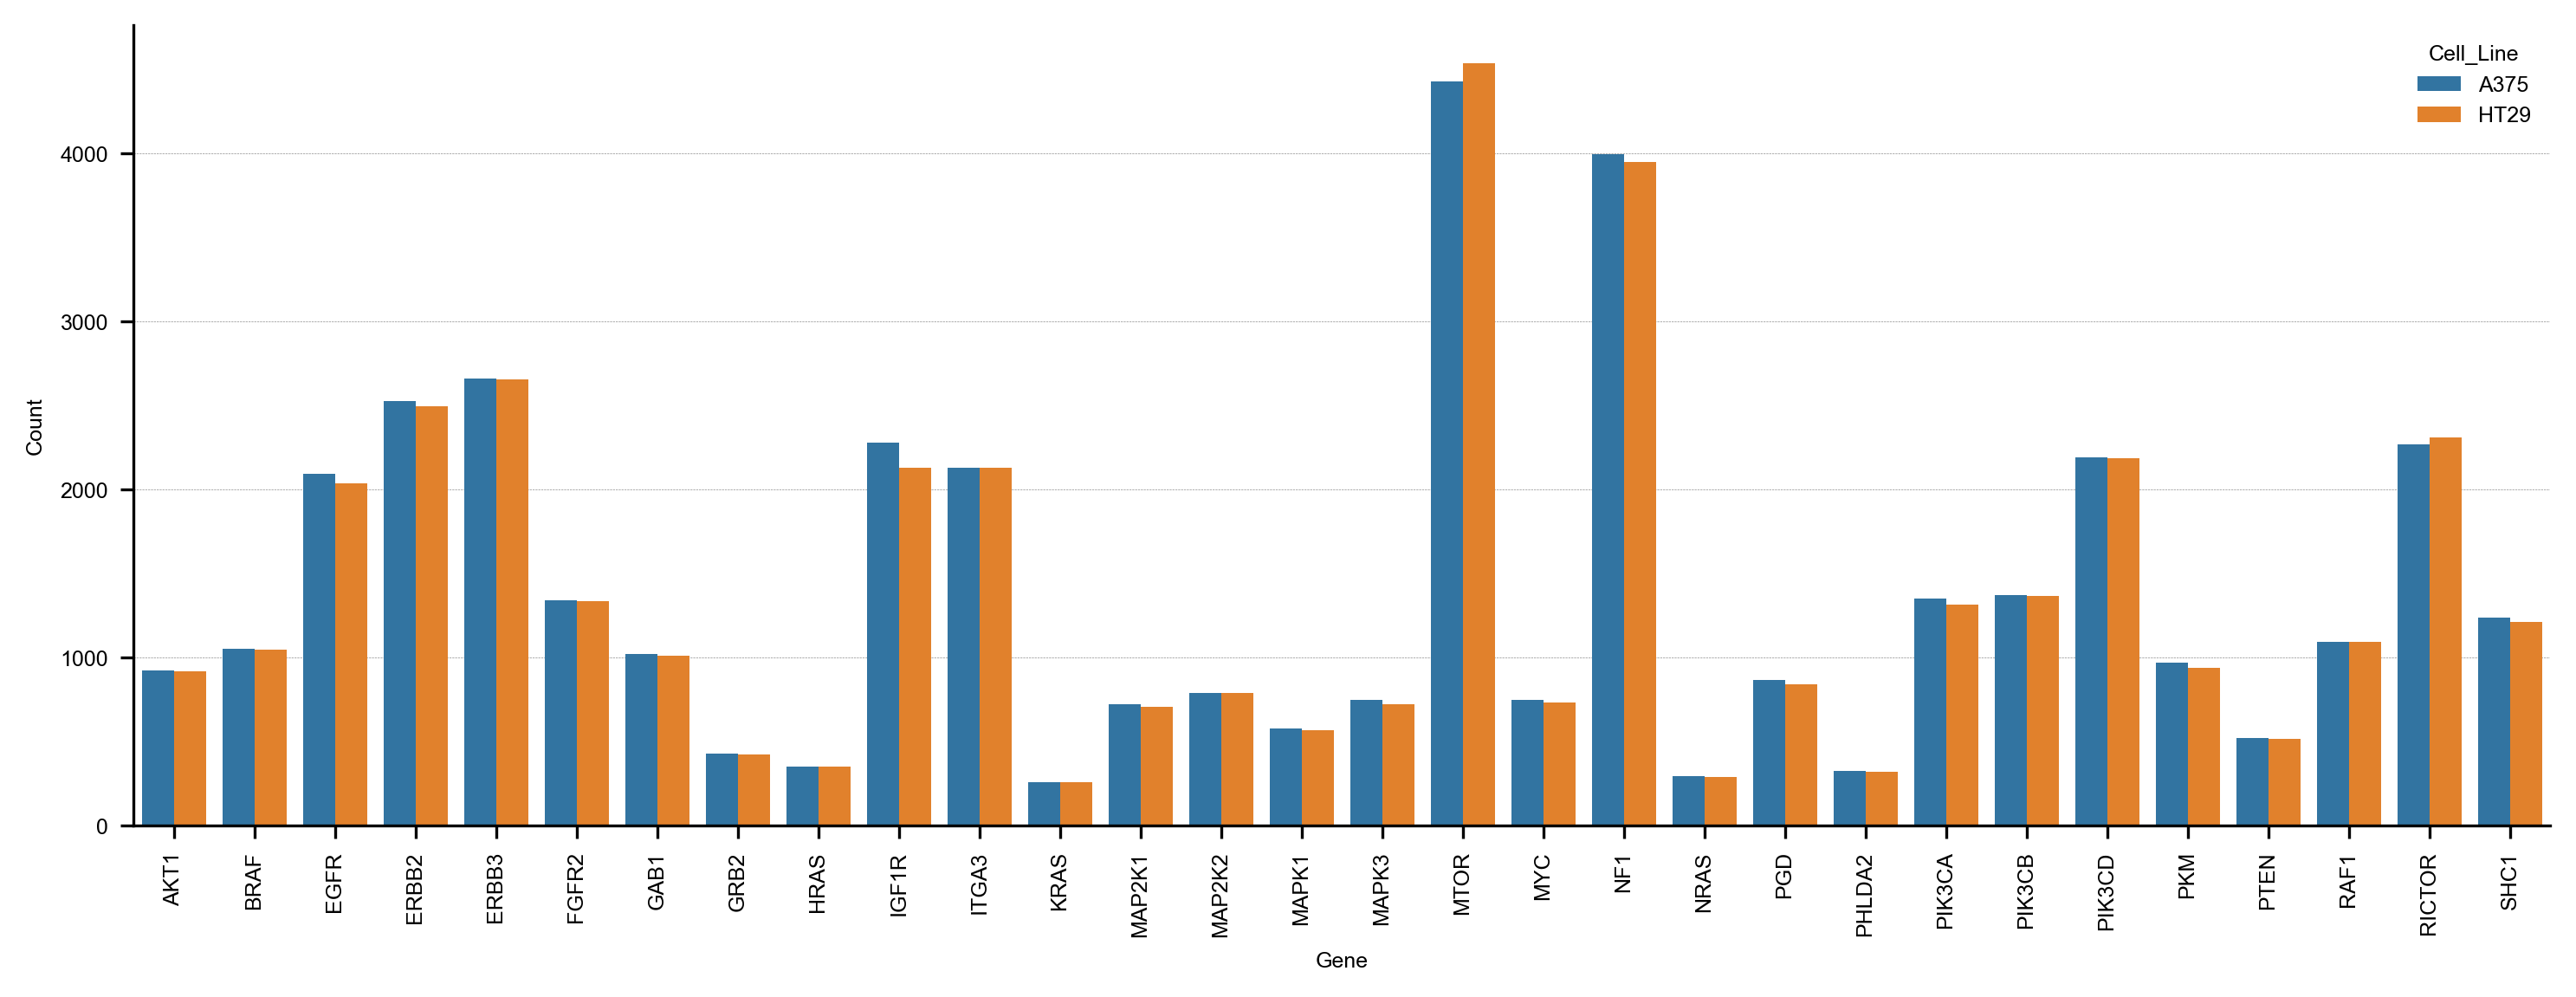

In [12]:
counts_before_DS = (
    annotated_variants_df
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", hue='Cell_Line', errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [12]:
def stratified_downsampling(df, class_col, random_state=None):
    #Infer majority class + target size (length of the second largest class)
    class_counts = df[class_col].value_counts()
    majority_class = class_counts.idxmax()
    target_size = class_counts.nlargest(2).iloc[-1]

    #Separate majority class and other classes
    major_df = df[df[class_col] == majority_class]
    other_df = df[df[class_col] != majority_class]

    # If majority already not bigger than target, nothing to do
    if len(major_df) <= target_size:
        return df.copy()
    
    #Compute distribution of the majority df across Cell_Line and Gene
    major_distribution = (
        major_df
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    major_distribution['Proportion'] = major_distribution['Count'] / major_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene group
    major_distribution['Target'] = np.floor(major_distribution['Proportion'] * target_size).astype(int)

    # Adjust target to ensure total matches target size 
    # i.e., distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_size - major_distribution['Target'].sum()
    if difference > 0:
        fractional_parts = major_distribution['Proportion'] * target_size - major_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        major_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_major_dfs= []
    for _, row in major_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']

        subset = major_df[(major_df['Cell_Line'] == cell_line) & (major_df['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case it is a very small group - but can lead to less samples than target_size overall
            downsampled_major_dfs.append(subset.sample(n=n_sampled, random_state=random_state))
    
    #Keep the indices until after the Top up step
    downsampled_majority_class_df = pd.concat(downsampled_major_dfs, axis=0)

    #Top up if needed (if very small groups caused total to be less than target_size)
    current_size = len(downsampled_majority_class_df)
    missing = target_size - current_size

    if missing>0: #ask supervisor if this is really needed
        remaining_samples = major_df.loc[~major_df.index.isin(downsampled_majority_class_df.index)]
        assert not remaining_samples.empty, ("Logic error: remaining_samples is empty but target_size not reached.")
        extra_n= min(missing, len(remaining_samples))
        extra_samples = remaining_samples.sample(n=extra_n, random_state=random_state)

        #Random subsample from the remaining samples now
        downsampled_majority_class_df = pd.concat([downsampled_majority_class_df, extra_samples], axis=0)

    # Reset index only at the end
    downsampled_majority_class_df = downsampled_majority_class_df.reset_index(drop=True)

    #Combine downsampled majority class with other classes
    balanced_df = pd.concat([downsampled_majority_class_df, other_df], ignore_index=True)

    return balanced_df

In [14]:
#Balanced Dataset
annotated_variants_df_balanced = stratified_downsampling(annotated_variants_df,class_col='Class', random_state=1)

In [25]:
print("Final class counts:")
print(annotated_variants_df_balanced["Class"].value_counts())

Final class counts:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64


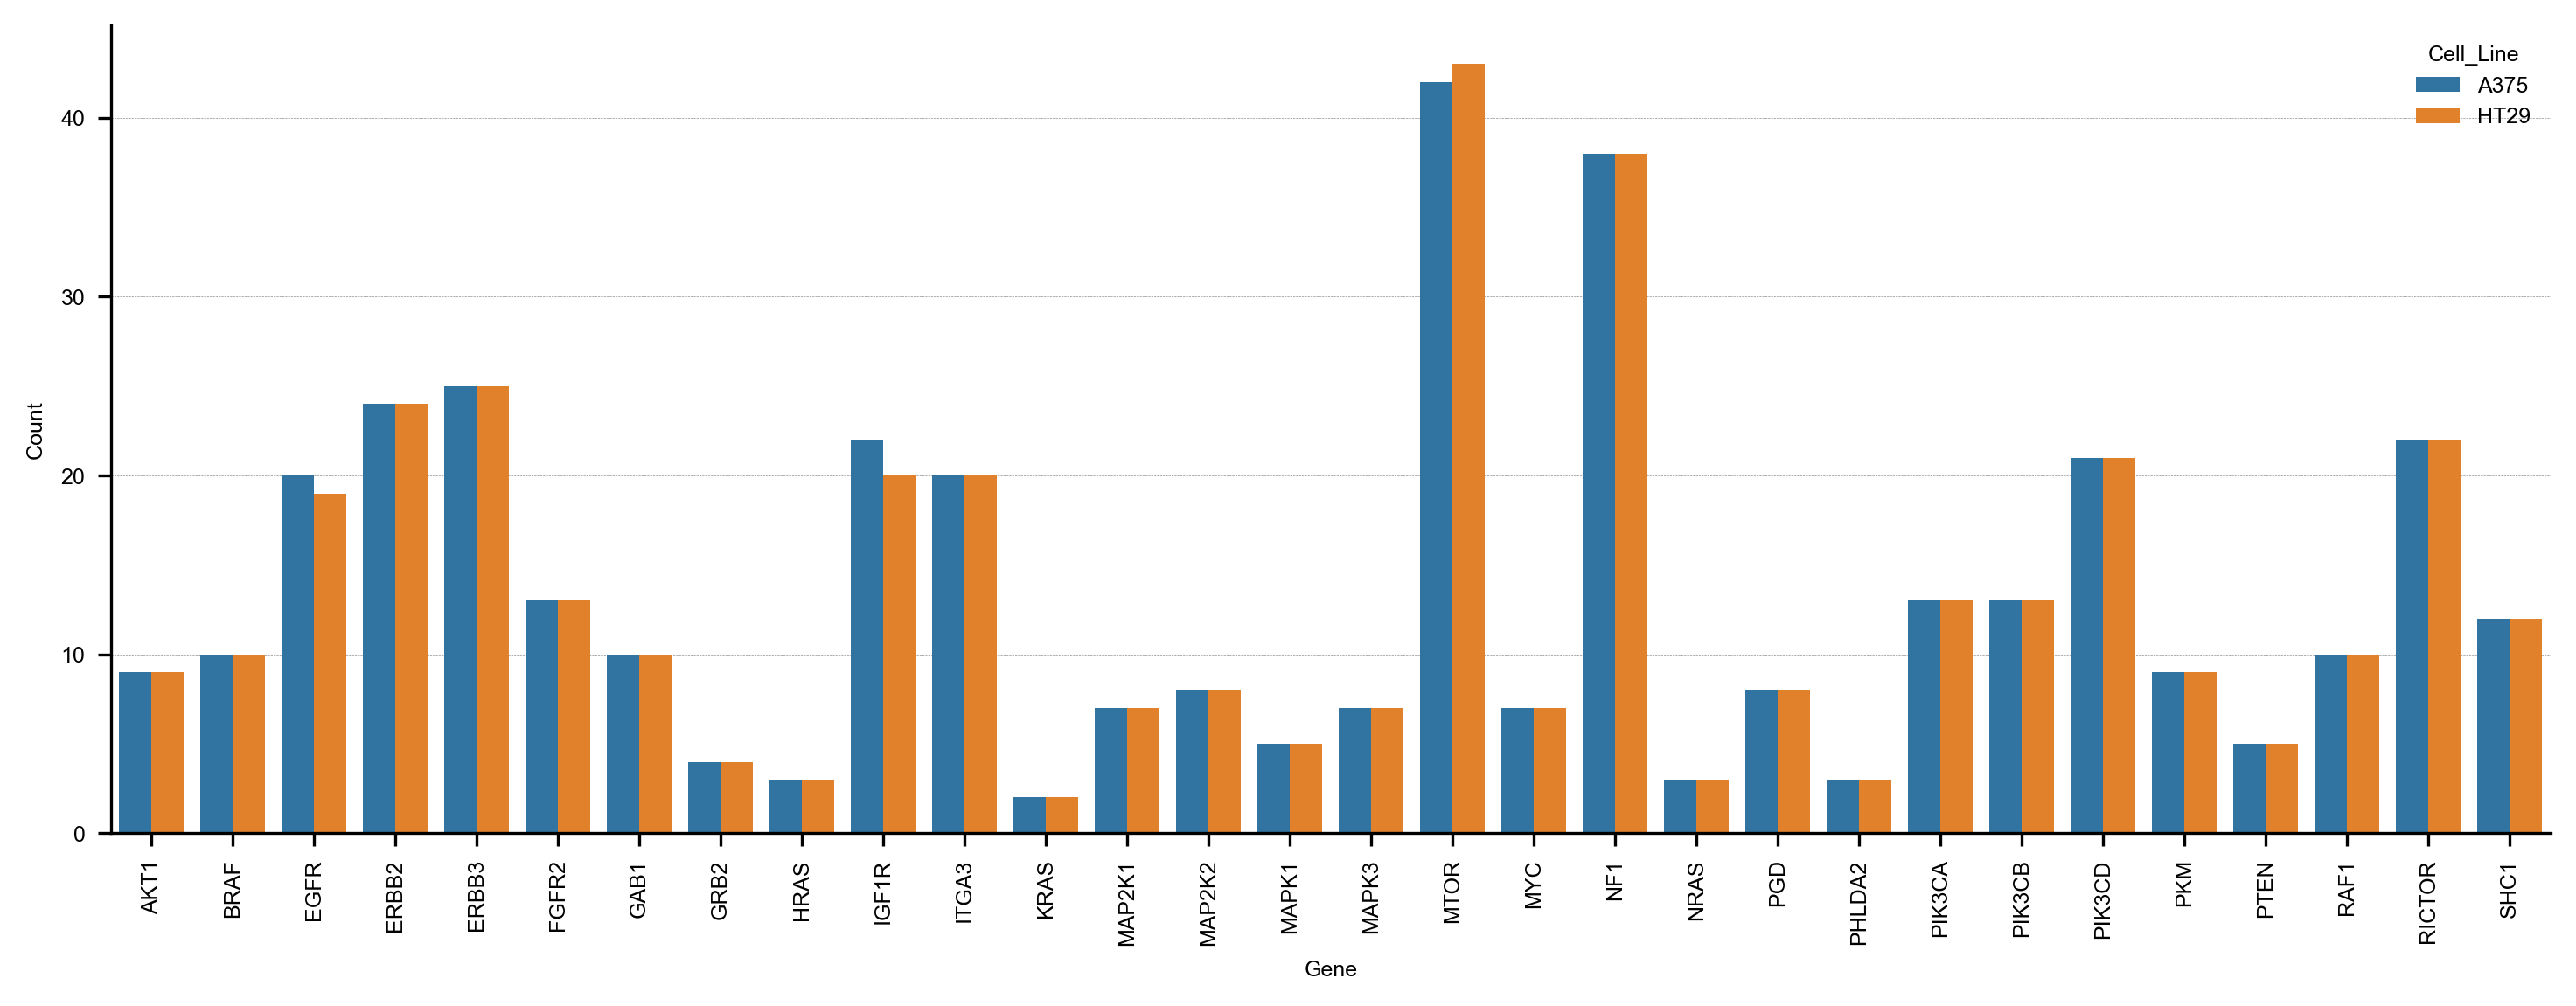

In [26]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_variants_df_balanced
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", hue="Cell_Line", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [27]:
comparison_df = pd.DataFrame({
    'Before_Downsampling': annotated_variants_df['Class'].value_counts().sort_index(),
    'After_Downsampling': annotated_variants_df_balanced['Class'].value_counts().sort_index()
}).reset_index().rename(columns={'index': 'Class'})
comparison_df

,Class,Before_Downsampling,After_Downsampling
0,Neutral,82785,788
1,Resistance,788,788
2,Sensitivity,451,451


In [28]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Cell_Line", "Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Cell_Line", "Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on=["Cell_Line", "Gene"], how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 10 rows):")
print(prop_compare.head(10))

Correlation of per-group proportions (before vs after downsampling): 0.9996

Proportion comparison (first 10 rows):
  Cell_Line   Gene  Proportion_before_DS  Proportion_after_DS
0      A375   AKT1                0.0112               0.0114
1      A375   BRAF                0.0127               0.0127
2      A375   EGFR                0.0253               0.0254
3      A375  ERBB2                0.0305               0.0305
4      A375  ERBB3                0.0321               0.0317
5      A375  FGFR2                0.0162               0.0165
6      A375   GAB1                0.0123               0.0127
7      A375   GRB2                0.0052               0.0051
8      A375   HRAS                0.0043               0.0038
9      A375  IGF1R                0.0276               0.0279


# Modeling

In [13]:
#Define meta data columns to drop
meta_cols=[
    'Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore', 'Source', 'Target Transcript ID', 'uniprot_accession',
    'RefSeq match transcript (MANE Select)', 'Amino Acid Edits', 'aa_change', 'pocket_id', 'Class'
]

vep_features = [
    'Mutation_Category_enc',
    'IMPACT_enc',
    'TSL',
    'SIFT_pathogenicity',
    'PolyPhen_pathogenicity',
    'REVEL',
    'ClinPred',
    'EVE_SCORE',
    'AlphaMissense_score',
    'BayesDel_noAF_score',
    'DANN_score',
    'DEOGEN2_score',
    'ESM1b_score',
    'Eigen-PC-phred_coding',
    'Eigen-PC-raw_coding',
    'GERP++_NR',
    'GERP++_RS',
    'LIST-S2_score',
    'MPC_rankscore',
    'MPC_score',
    'MVP_score',
    'MetaRNN_score',
    'MetaSVM_score',
    'MutFormer_score',
    'MutationAssessor_score',
    'PROVEAN_score',
    'PrimateAI_pred_enc',
    'VARITY_R_LOO_score',
    'bStatistic',
    'fathmm-XF_coding_score',
    'gMVP_score',
    'phastCons100way_vertebrate',
    'phyloP100way_vertebrate',
    'CADD_PHRED',
    'MaxEntScan_alt',
    'MaxEntScan_diff',
    'MaxEntScan_ref',
    'SpliceAI_pred_DP_AG',
    'SpliceAI_pred_DP_AL',
    'SpliceAI_pred_DP_DG',
    'SpliceAI_pred_DP_DL',
    'SpliceAI_pred_DS_AG',
    'SpliceAI_pred_DS_AL',
    'SpliceAI_pred_DS_DG',
    'SpliceAI_pred_DS_DL',
    'BLOSUM62',
    'LOEUF',
    'mutfunc_exp',
    'ada_score'
]

cellular_drug_context_features = [
    'Gene_expression_voom',
    'CRISPR_essentiality_score',
    'protein_abundance_zscore',
    'gene_cn_total',
    'gene_cn_category_enc',
    'gene_cn_category_Amplification',
    'gene_cn_category_Gain',
    'gene_cn_category_Loss',
    'gene_cn_category_Neutral',
    'lnIC50',
    'drug_target_gene_distance',
    'is_drug_target'
]

protvar_features = [
    'foldx_ddg',
    'alphafold_plddt',
    'pocket_id',
    'min_pocket_buriedness',
    'pocket_plddt_mean',
    'pocket_score_combined_scaled',
    'CRISPR_essentiality_score',
    'is_in_interface',
    'interface_count'
]

In [82]:
#this functin will go on a .py file
def train_test_once(df, model, meta_cols, le, cv, stratified_downsampling, class_col, random_state_for_downsampling):

    #Perform stratified downsampling
    df_balanced = stratified_downsampling(df, class_col = class_col, random_state=random_state_for_downsampling)

    #Print class distribution after downsampling
    print("Class distribution after downsampling:")
    print(df_balanced[class_col].value_counts())

    #Separate train and test sets
    X = df_balanced.drop(columns=meta_cols + ["Class_encoded"])
    y = df_balanced["Class_encoded"]

    class_names = list(le.classes_)
    n_classes = len(class_names)

    fold_reports = []
    roc_auc_scores_weighted, roc_auc_scores_macro = [], []
    pr_auc_scores_weighted, pr_auc_scores_macro = [], []
    all_y_true, all_y_pred, all_probs = [], [], []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        probs = model.predict_proba(X_val) 


        #Store predictions, true labels and probabilities 
        #Predictions and labels are flattened across folds for global metrics
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
        all_probs.extend(probs)

        #ROC AUC
        roc_auc_scores_weighted.append(roc_auc_score(y_val, probs, multi_class="ovr", average='weighted'))
        roc_auc_scores_macro.append(roc_auc_score(y_val, probs, multi_class="ovr", average='macro'))

        #PR AUC
        pr_auc_scores_weighted.append(average_precision_score(y_val, probs, average='weighted'))
        pr_auc_scores_macro.append(average_precision_score(y_val, probs, average='macro'))

        fold_reports.append(classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True))


    # Aggregate metrics - average across folds 
    metrics = {}
    metrics["accuracy"] = np.mean([r["accuracy"] for r in fold_reports])

    for avg_key in ["macro avg", "weighted avg"]:
        metrics[f"precision_{avg_key}"] = np.mean([r[avg_key]["precision"] for r in fold_reports])
        metrics[f"recall_{avg_key}"] = np.mean([r[avg_key]["recall"] for r in fold_reports])
        metrics[f"f1_{avg_key}"] = np.mean([r[avg_key]["f1-score"] for r in fold_reports])

    for cname in class_names:
        metrics[f"precision_{cname}"] = np.mean([r[cname]["precision"] for r in fold_reports])
        metrics[f"recall_{cname}"] = np.mean([r[cname]["recall"]    for r in fold_reports])
        metrics[f"f1_{cname}"] = np.mean([r[cname]["f1-score"]  for r in fold_reports])

    metrics["roc_auc_weighted"] = np.mean(roc_auc_scores_weighted)
    metrics["roc_auc_macro"] = np.mean(roc_auc_scores_macro)
    metrics["pr_auc_weighted"] = np.mean(pr_auc_scores_weighted)
    metrics["pr_auc_macro"] = np.mean(pr_auc_scores_macro)

    cm = confusion_matrix(all_y_true, all_y_pred, labels=np.arange(len(le.classes_)))
    return metrics, cm, np.array(all_y_true), np.array(all_y_pred), np.array(all_probs)

### Define Model and Cross-Validation

In [33]:

optimized_params = {'n_estimators': 473,
                    'max_depth': 8,
                    'learning_rate': 0.014757846958987166,
                    'subsample': 0.9074779169306355,
                    'colsample_bytree': 0.5480484893807359,
                    'min_child_weight': 1,
                    'reg_alpha': 0.0004937375718649116,
                    'reg_lambda': 0.000319094062330884,
                    'gamma': 0.6244886434704836}

#Define optimized XGBClassifier with Optuna parameters  
xgb_classifier_optimized = XGBClassifier(
    **optimized_params                   
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Run Model

In [83]:
# Run multiple times to get average performance across different downsamplings
n_runs = 10
all_metrics, all_cms = [], []
all_y_true_runs, all_y_pred_runs, all_probs_runs = [], [], []

for i in range(n_runs):
    print(f"\n--- Run {i+1}/{n_runs} ---")
    metrics, cm, y_true, y_pred, probs = train_test_once(
        df=annotated_variants_df,
        model=xgb_classifier_optimized,
        meta_cols=meta_cols,
        le=le,
        cv=skf,
        stratified_downsampling=stratified_downsampling,
        class_col='Class',
        random_state_for_downsampling=i
    )
    all_metrics.append(metrics)
    all_cms.append(cm)
    all_y_true_runs.append(y_true)
    all_y_pred_runs.append(y_pred)
    all_probs_runs.append(probs)

    print("Metrics:", metrics)
    print("Confusion Matrix:\n", cm)

#Aggregate metrics across runs
metrics_df = pd.DataFrame(all_metrics)
metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

cm_mean = np.mean(np.array(all_cms, dtype=float), axis=0)
cm_std  = np.std(np.array(all_cms, dtype=float), axis=0)

# Reorder confusion matrix
desired_order = ["Sensitivity", "Neutral", "Resistance"]

# Map to label encoder indices
reorder_idx = [list(le.classes_).index(c) for c in desired_order]

# Reorder rows and columns
cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

# Update class_names for correct axis labels
class_names_reordered = desired_order

print("=== Mean metrics ===")
print(metrics_mean)
print("\n=== Std metrics ===")
print(metrics_std)

print("\n=== Mean confusion matrix ===")
print(cm_mean)
print("\n=== Std confusion matrix ===")
print(cm_std)


--- Run 1/10 ---
Class distribution after downsampling:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64
Metrics: {'accuracy': np.float64(0.7010326582740376), 'precision_macro avg': np.float64(0.7074044213481308), 'recall_macro avg': np.float64(0.6877179996135088), 'f1_macro avg': np.float64(0.6945049073175587), 'precision_weighted avg': np.float64(0.7044389540009026), 'recall_weighted avg': np.float64(0.7010326582740376), 'f1_weighted avg': np.float64(0.7001294597500534), 'precision_Neutral': np.float64(0.6663384013689981), 'recall_Neutral': np.float64(0.7525114891558495), 'f1_Neutral': np.float64(0.7067229987048147), 'precision_Resistance': np.float64(0.7304936407023882), 'recall_Resistance': np.float64(0.7030234620656293), 'f1_Resistance': np.float64(0.7160738629074462), 'precision_Sensitivity': np.float64(0.7253812219730063), 'recall_Sensitivity': np.float64(0.6076190476190477), 'f1_Sensitivity': np.float64(0.6607178603404152), 'roc_auc_weig

### Get Metrics

In [18]:
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

   # === Confusion Matrix summary ===
    cm_array = np.stack(cms)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # === Reorder ===
    desired_order = ["Sensitivity", "Neutral", "Resistance"]
    reorder_idx = [list(class_names).index(c) for c in desired_order]

    cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
    cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

    class_names = desired_order

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   
            std_val = int(cm_std[i, j])       
            combined[i, j] = f"{mean_val}±{std_val}"


    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 8})
    #plt.title("Confusion Matrix (mean ± std)")
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.ylabel("True Label", fontsize=9)
    plt.show()

# === Bar plot: Precision & Recall per class (mean ± std) ===
    precision_means = [summary[f"precision_{c}"][0] for c in class_names]
    precision_stds  = [summary[f"precision_{c}"][1] for c in class_names]
    recall_means    = [summary[f"recall_{c}"][0] for c in class_names]
    recall_stds     = [summary[f"recall_{c}"][1] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(6, 5))
    bars1 = plt.bar(x - width/2, precision_means, width,
                    yerr=precision_stds, capsize=3,
                    label="Precision", color="lightsteelblue")
    bars2 = plt.bar(x + width/2, recall_means, width,
                    yerr=recall_stds, capsize=3,
                    label="Recall", color="midnightblue")

    # Add numbers on top
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

    plt.xticks(x, class_names, fontsize=8)
    plt.ylabel("Score", fontsize=10)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=6)
    plt.show()

    return summary, cm_mean, cm_std


=== Metrics Summary (mean ± std) ===
accuracy            : 0.706 ± 0.003
roc_auc_weighted    : 0.848 ± 0.003
roc_auc_macro       : 0.851 ± 0.003
pr_auc_weighted     : 0.767 ± 0.006
pr_auc_macro        : 0.764 ± 0.006
precision_macro avg : 0.713 ± 0.004
recall_macro avg    : 0.693 ± 0.003
f1_macro avg        : 0.700 ± 0.003
precision_weighted avg: 0.710 ± 0.004
recall_weighted avg : 0.706 ± 0.003
f1_weighted avg     : 0.705 ± 0.003

=== Class-wise Metrics (mean ± std) ===
Neutral    precision : 0.671 ± 0.003
Neutral    recall    : 0.763 ± 0.008
Neutral    f1        : 0.714 ± 0.004
Resistance precision : 0.736 ± 0.011
Resistance recall    : 0.700 ± 0.004
Resistance f1        : 0.716 ± 0.006
Sensitivity precision : 0.732 ± 0.012
Sensitivity recall    : 0.617 ± 0.007
Sensitivity f1        : 0.669 ± 0.009


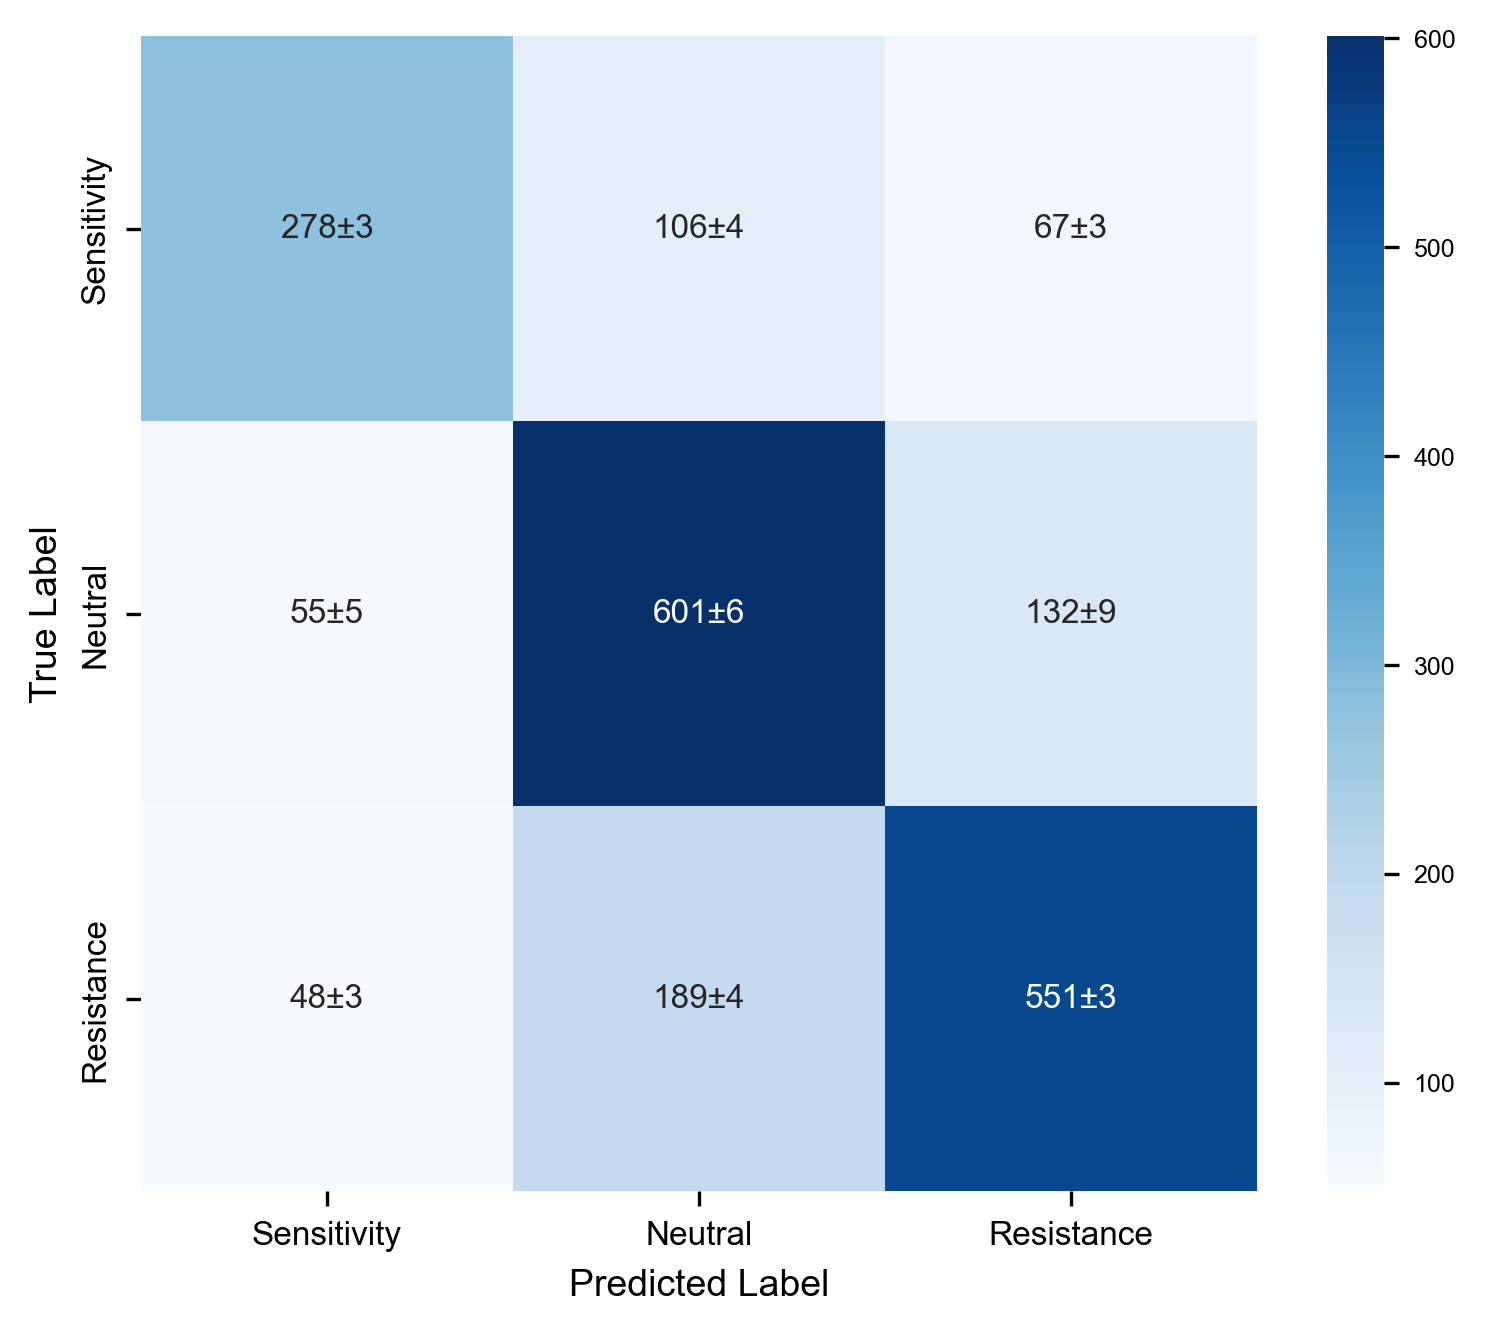

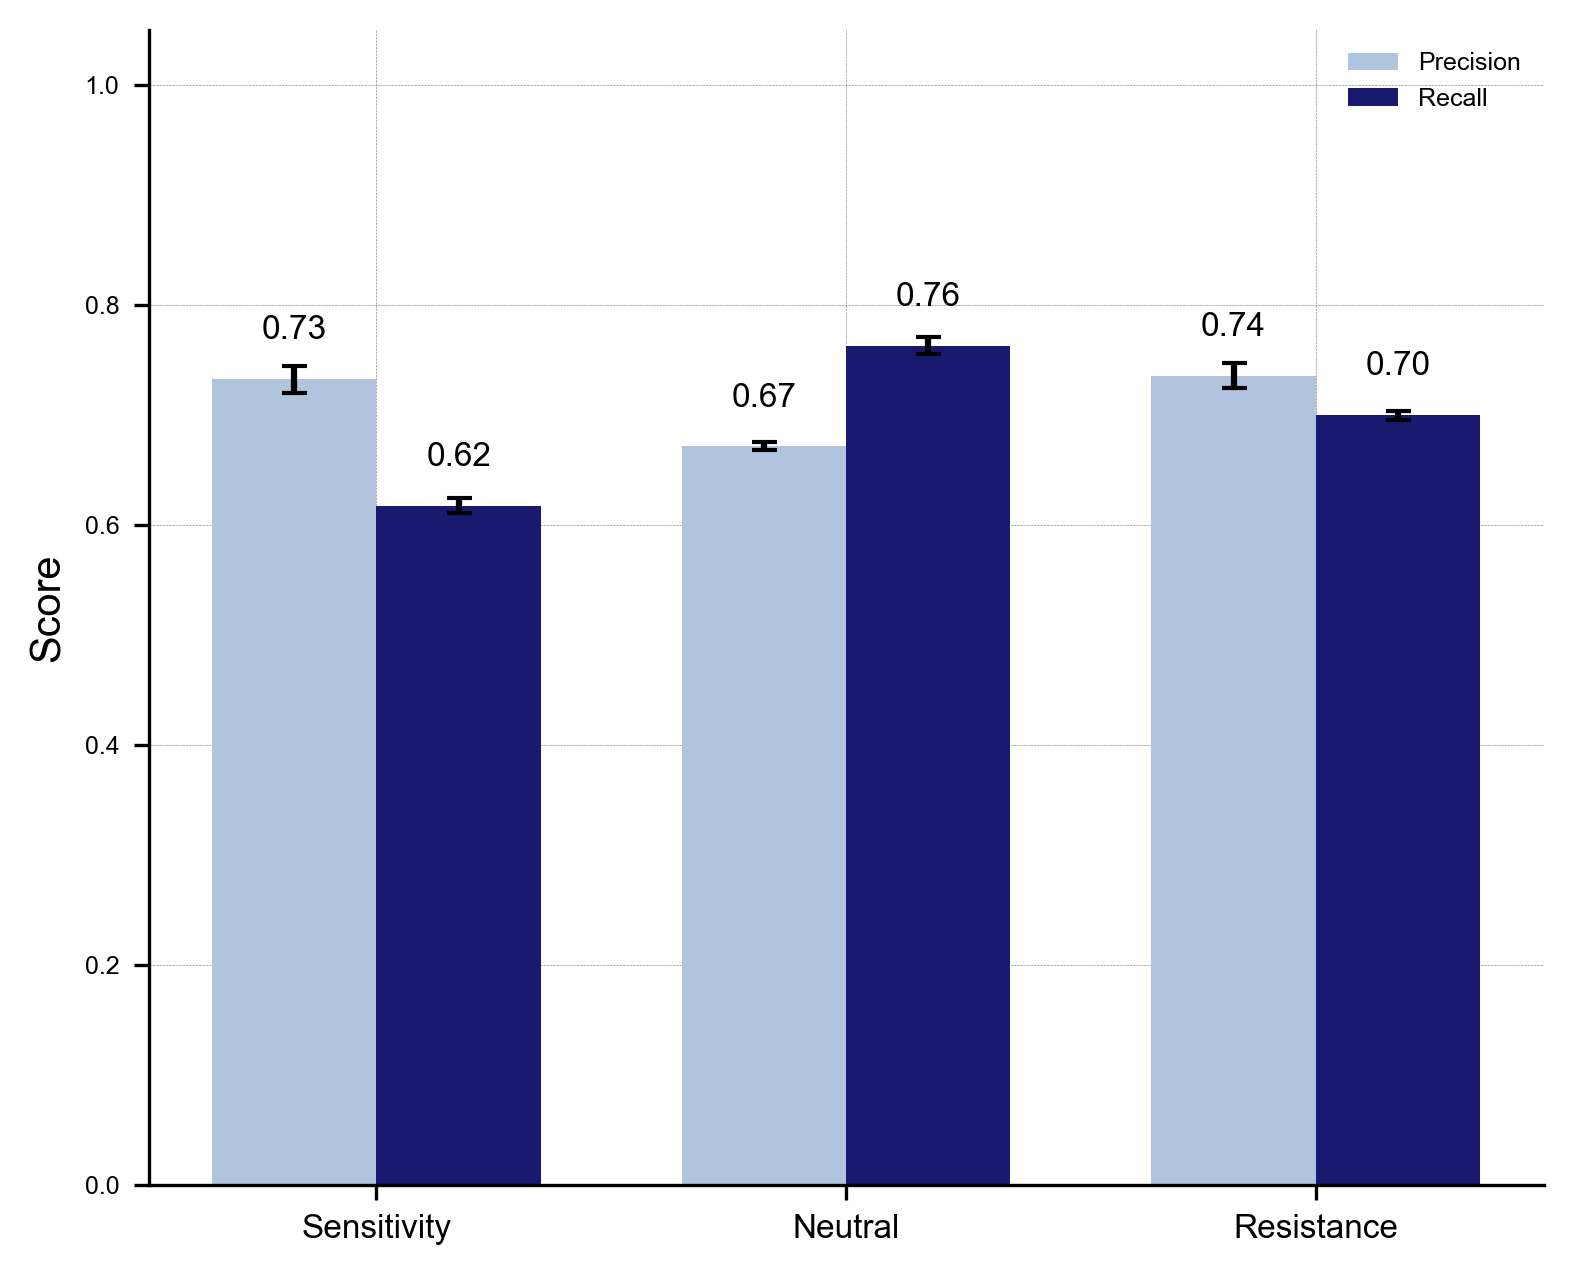

In [84]:
metrics_summary, cm_mean, cm_std = summarize_results(all_metrics, all_cms,
                                                     class_names=le.classes_)

### F1 plot per class

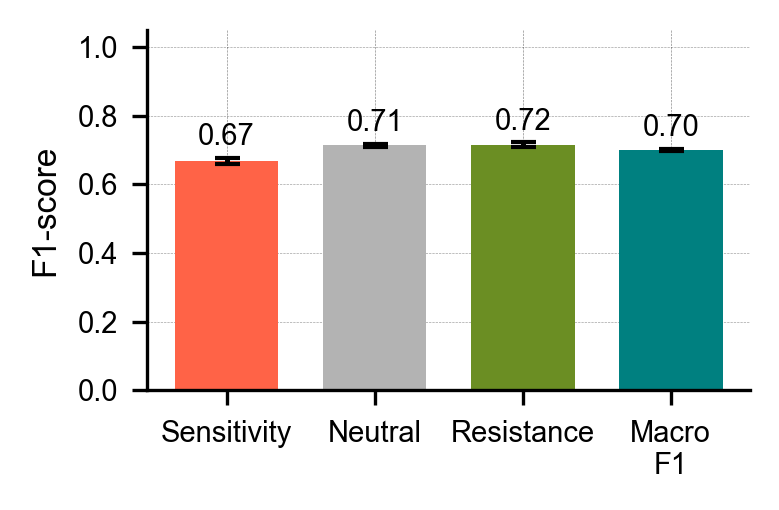

In [106]:
# Define your desired class order (using the metric keys used to index all metrics )
class_order = ["Sensitivity", "Neutral", "Resistance", 'macro avg']

# Display labels for the x-axis
display_labels = ["Sensitivity", "Neutral", "Resistance", "Macro\nF1"]

# Compute mean and std in that order
f1_means = [np.mean([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]
f1_stds  = [np.std([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]

# Define consistent colors for each class
colors_bar = ["tomato", "#b3b3b3", "olivedrab", "teal"]

x = np.arange(len(display_labels))
plt.figure(figsize=(2.7,1.8))

bars = plt.bar(x, f1_means, yerr=f1_stds, capsize=3, color=colors_bar, width = 0.7, error_kw=dict(ecolor='black', lw=1.2))

# Add value labels
#for i, bar in enumerate(bars):
    #height = bar.get_height()
    #plt.text(bar.get_x() + bar.get_width()/2, height + 0.075, f"{height:.2f}", ha='center', va='bottom', fontsize=8)

for i, bar in enumerate(bars):
    mean = f1_means[i]
    std = f1_stds[i]

    plt.text(bar.get_x() + bar.get_width()/2,
             mean + std + 0.02,
             f"{mean:.2f}",
             ha='center', va='bottom', fontsize=7)

plt.xticks(x, display_labels, fontsize=7)
plt.ylabel("F1-score", fontsize=8)
plt.yticks(fontsize=7)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [72]:
#Save the dataset used for the F1 plot
f1_results_to_plot_df = pd.DataFrame({
    "Class": class_order,
    "F1_mean": f1_means,
    "F1_std": f1_stds
})

f1_results_to_plot_df.to_csv("/Users/carolinapinto/desktop/Tese/Plots/Benchmarking/f1_scores_across_10_runs_plot_benchmark1.csv", index=False)

### PR Curve

In [94]:
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(4,3))

for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(recall_grid, mean_precision, color=colors[i], lw=2, label=f"{class_name} (AUC = {mean_auc:.2f})")
    plt.fill_between(recall_grid, mean_precision - std_precision, mean_precision + std_precision,
                     color=colors[i], alpha=0.2)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)


plt.plot(recall_grid, mean_macro, color='black', lw=2, linestyle='--', label=f"Macro-average (AUC = {mean_auc_macro:.2f})")
plt.fill_between(recall_grid, mean_macro - std_macro, mean_macro + std_macro, color='black', alpha=0.2)

plt.xlabel("Recall", fontsize=10)
plt.xticks(fontsize=8)
plt.ylabel("Precision", fontsize=10)
plt.yticks(fontsize=8)
plt.legend(fontsize=8, loc="lower left", frameon=False, bbox_to_anchor=(0.03, 0.02))
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

NameError: name 'all_y_true_runs' is not defined

<Figure size 1200x900 with 0 Axes>

In [74]:
#Save PR curve data for reproducibility
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

#Store all PR curves data 
all_pr_dfs = []
for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    #Dataframe with the per-class PR curve data for reproducibility
    df_class = pd.DataFrame({
        "Recall": recall_grid,
        "Mean_Precision": mean_precision,
        "Std_Precision": std_precision,
        "Class": class_name,
        "Mean_AUC": mean_auc,
        "Std_AUC": std_auc
    })
    all_pr_dfs.append(df_class)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)

df_macro = pd.DataFrame({
    "Recall": recall_grid,
    "Mean_Precision": mean_macro,
    "Std_Precision": std_macro,
    "Class": "Macro-average",
    "Mean_AUC": mean_auc_macro,
    "Std_AUC": std_auc_macro
})
all_pr_dfs.append(df_macro)

#Combine all into a single dataframe
pr_curve_data_df = pd.concat(all_pr_dfs, ignore_index=True)
pr_curve_data_df.to_csv("/Users/carolinapinto/desktop/Tese/Plots/Benchmarking/pr_curve_data_across_10_runs_plot_benchmark1.csv", index=False)

## SHAP

Train the model once on the entire dataset and compute SHAP

In [19]:
#Prepare X and y
X= annotated_variants_df_balanced.drop(columns=meta_cols + ["Class_encoded"])
y= annotated_variants_df_balanced["Class_encoded"]
meta_data = annotated_variants_df_balanced[meta_cols]

#Train final model on the entire balanced dataset
final_model = XGBClassifier(**optimized_params)
final_model.fit(X, y)

#Predict y (for shap UMAP with predicted class)
y_pred_final = final_model.predict(X)

#Compute SHAP values on the training data (since we don't have a separate test set)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

In [20]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(2027, 68, 3)


In [74]:
def get_stacked_shap_for_class(shap_values, X, le, target_class):
    
    class_idx = list(le.classes_).index(target_class)
    shap_c = shap_values[:, :, class_idx]

    assert shap_c.shape[0] == X.shape[0], "Row mismatch after stacking"
    return shap_c, X

def top_k_features_by_mean_abs_shap(shap_c, X, k=10):
    mean_abs = np.mean(np.abs(shap_c), axis=0)
    s = pd.Series(mean_abs, index=X.columns).sort_values(ascending=False)
    return s.head(k)  #Series: index=feature, value=mean|SHAP|


def plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class, k=10):
    shap_c, X = get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class)

    topk = top_k_features_by_mean_abs_shap(shap_c, X, k=k)
    top_features = topk.index.tolist()

    # Subset to top-k features
    cols_idx = [X.columns.get_loc(f) for f in top_features]
    shap_top = shap_c[:, cols_idx]
    X_top = X[top_features]

    print(f"\n=== {target_class}: Top {k} by mean(|SHAP|) ===")
    print(topk)


    # Bar: mean absolute SHAP
    shap.summary_plot(shap_top, X_top, plot_type="bar", max_display=k, plot_size=(6, 2), show=False)
    plt.xlabel("Mean |SHAP value|", fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Beeswarm: distribution + direction
    shap.summary_plot(shap_top, X_top, max_display=k, plot_size=(6, 3), show=False)
    plt.xlabel("SHAP value", fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    #plt.xlim(-1, 1)

    fig = plt.gcf()
    axes = fig.axes

    # The last axis is the colorbar
    cbar_ax = axes[-1]

    # Change tick label size (Low / High numbers if present)
    cbar_ax.tick_params(labelsize=10)

    # Change colorbar label size
    cbar_ax.set_ylabel("Feature value", fontsize=11)

    plt.tight_layout()
    plt.show()



=== Sensitivity: Top 5 by mean(|SHAP|) ===
lnIC50                       0.297431
CRISPR_essentiality_score    0.246881
protein_abundance_zscore     0.213094
Gene_expression_voom         0.161175
LOEUF                        0.080527
dtype: float32


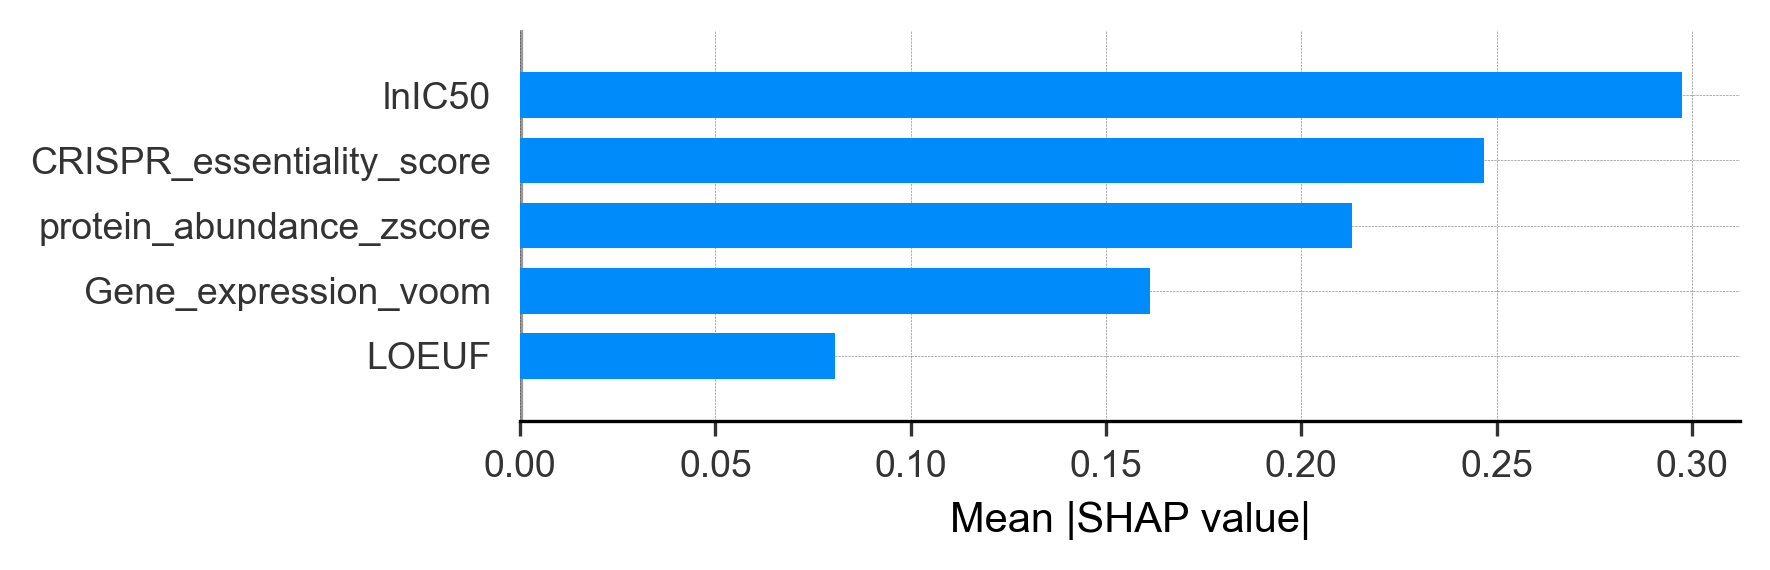

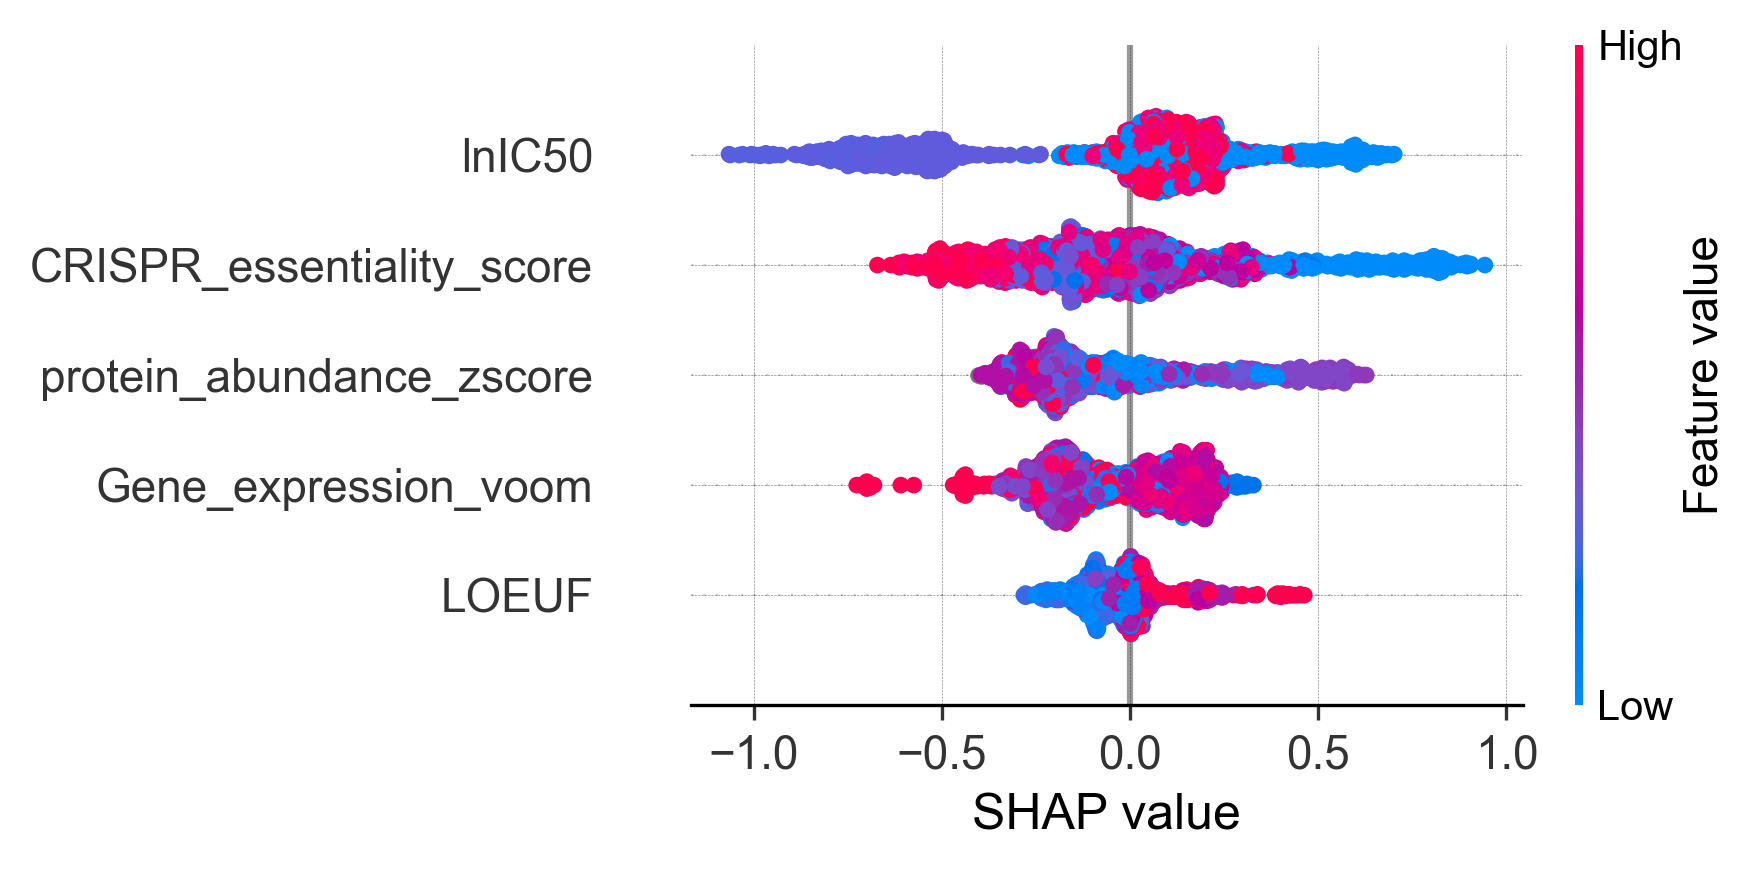

In [75]:
plot_topk_shap_for_class(shap_values, X, le, target_class='Sensitivity', k=5)


=== Neutral: Top 5 by mean(|SHAP|) ===
lnIC50                       0.239908
CRISPR_essentiality_score    0.204573
CADD_PHRED                   0.203502
BayesDel_noAF_score          0.078622
protein_abundance_zscore     0.056028
dtype: float32


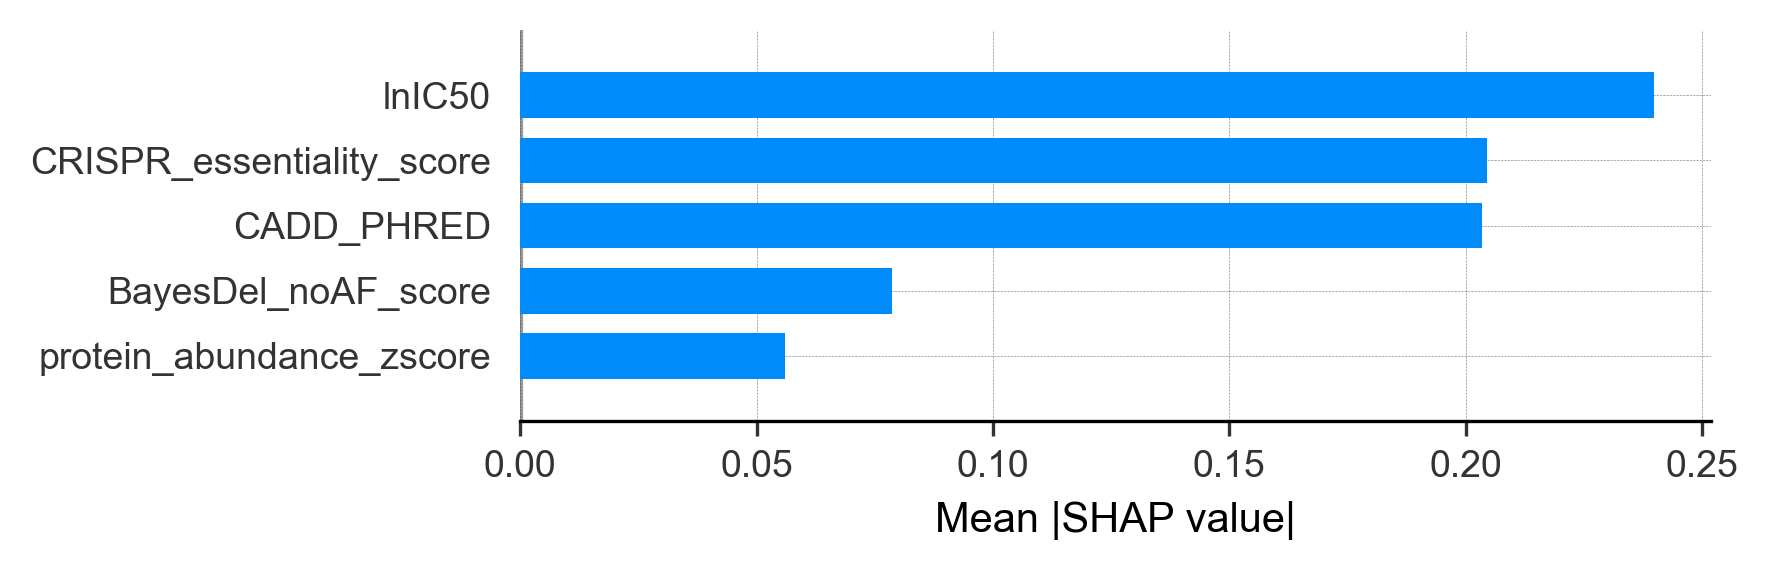

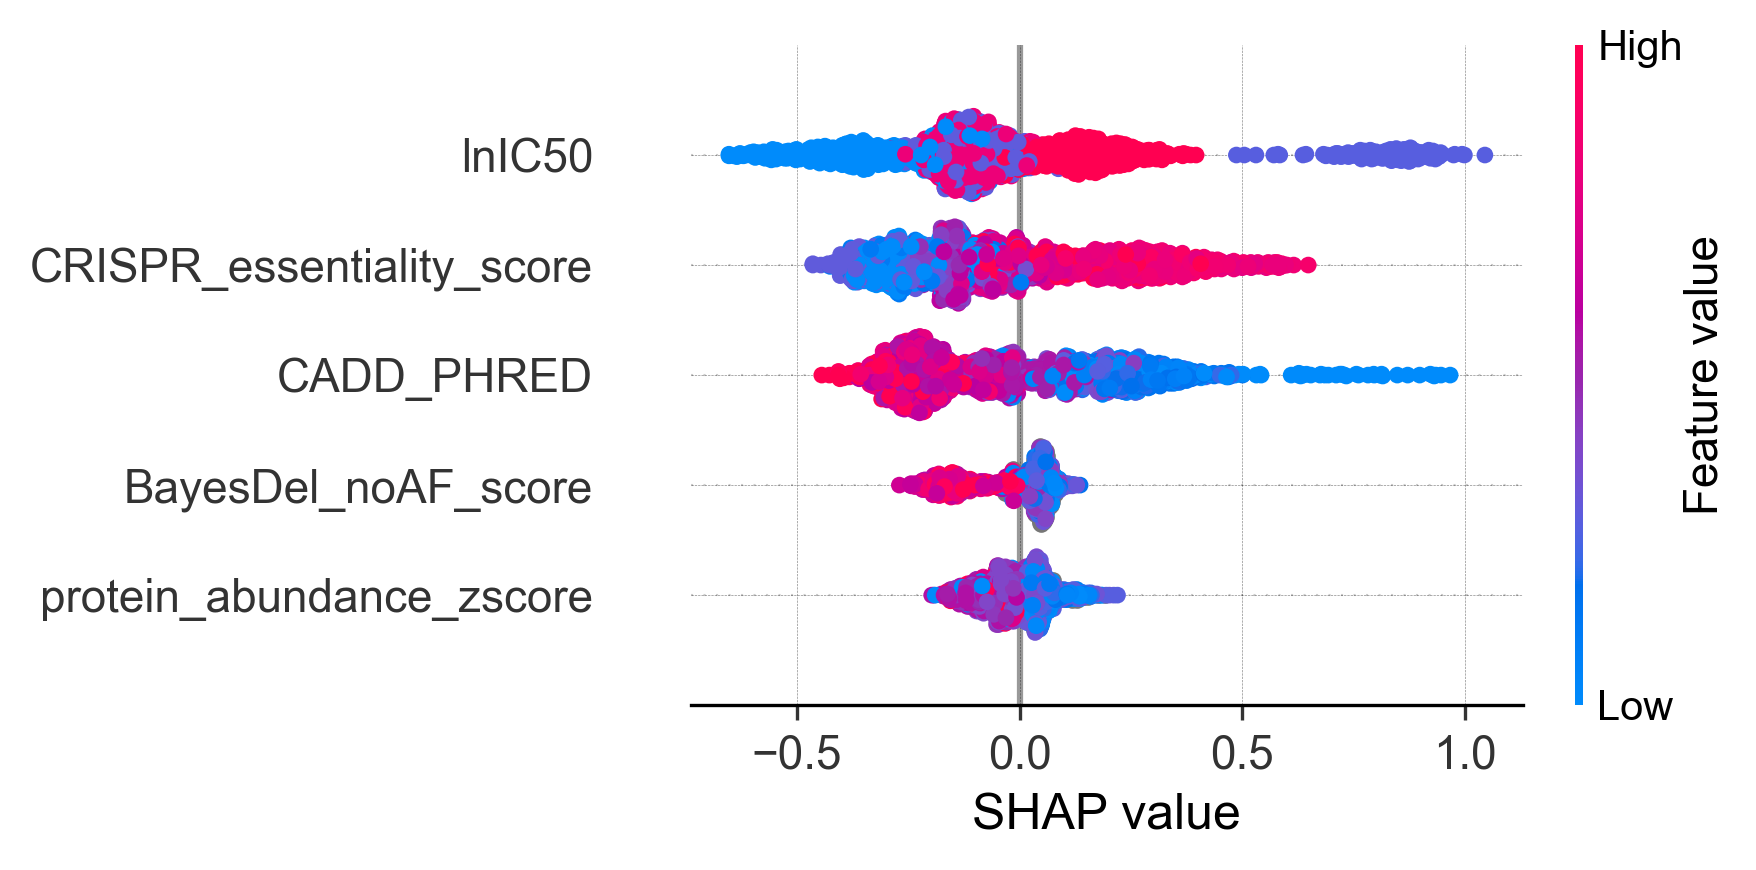

In [76]:
plot_topk_shap_for_class(shap_values, X, le, target_class='Neutral', k=5)


=== Resistance: Top 5 by mean(|SHAP|) ===
lnIC50                       0.184512
protein_abundance_zscore     0.152405
gene_cn_total                0.099713
CRISPR_essentiality_score    0.084742
Gene_expression_voom         0.076313
dtype: float32


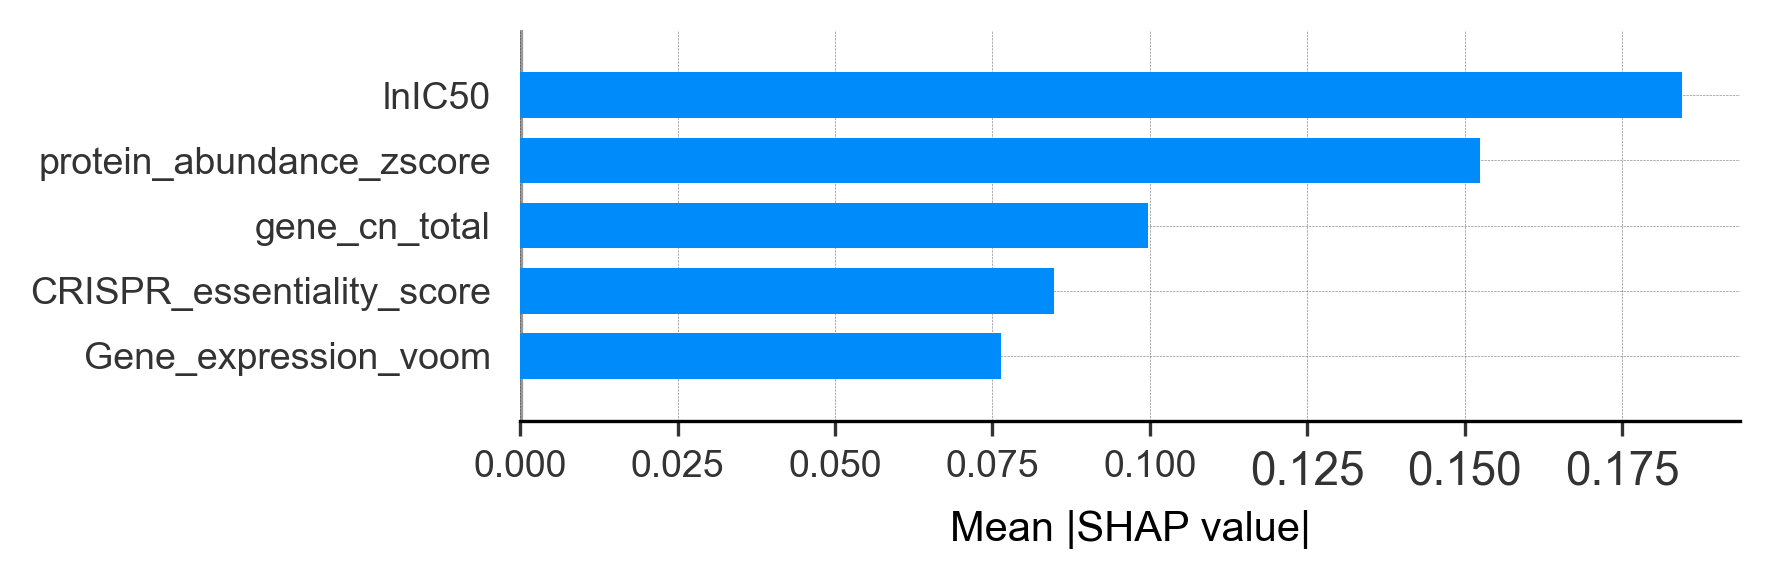

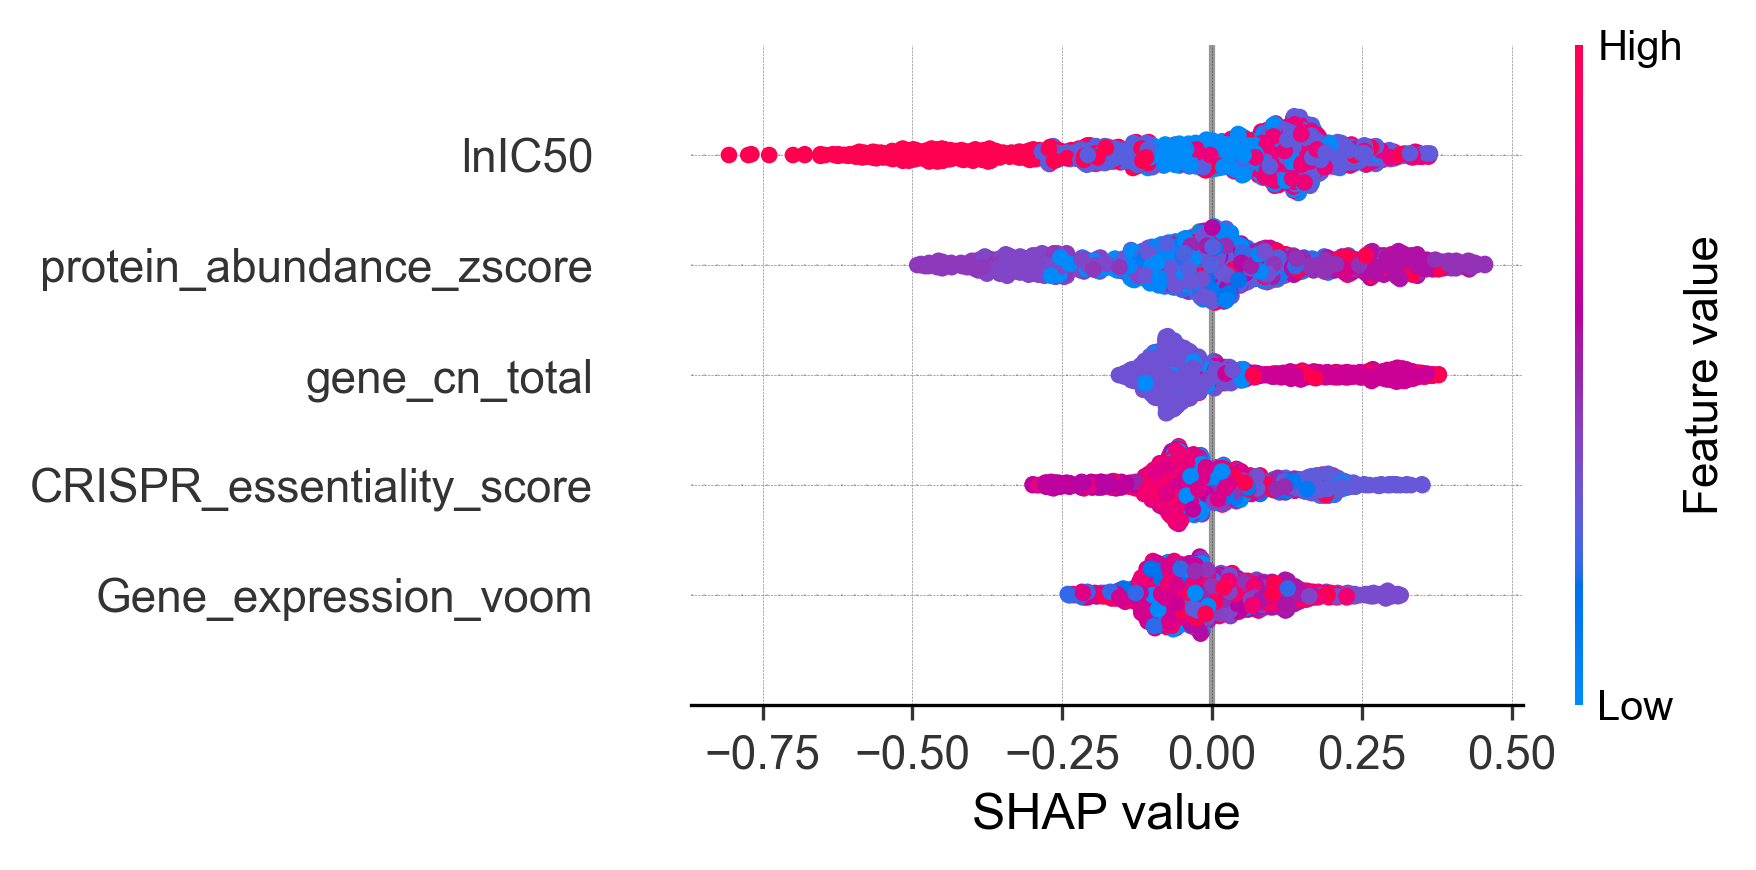

In [77]:
plot_topk_shap_for_class(shap_values, X, le, target_class='Resistance', k=5)

### SHAP UMAP

In [23]:
def get_shap_predicted_class(shap_values, y_pred):
    """
    Get SHAP values corresponding to the predicted class for each sample.
    """
    assert shap_values.shape[0] == len(y_pred)
    return shap_values[np.arange(len(y_pred)), :, y_pred]

def get_shap_umap_embedding(shap_matrix, n_neighbors=15, min_dist=0.1, random_state=42, scale=True):
    """
    Run UMAP on SHAP vectors.
    shap_values: (n_samples, n_features)
    """
    X_embed = shap_matrix.copy()

    if scale:
        #SHAP values can have different ranges across features
        X_embed= StandardScaler().fit_transform(X_embed)
    
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=random_state)

    embedding = reducer.fit_transform(X_embed)
    return embedding

def plot_umap(embedding, color=None, cmap="viridis"):
    plt.figure(figsize=(6, 5))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=color,
        cmap=cmap,
        s=6,
        alpha=0.7
    )
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()

In [25]:
#SHAP of the predicted class for each sample
shap_pred= get_shap_predicted_class(shap_values, y_pred_final)

#SHAP per class
idx_sensitivity = list(le.classes_).index("Sensitivity")
idx_neutral = list(le.classes_).index("Neutral")
idx_resistance = list(le.classes_).index("Resistance")

shap_sensitivity = shap_values[:, :, idx_sensitivity]
shap_neutral = shap_values[:, :, idx_neutral]
shap_resistance = shap_values[:, :, idx_resistance]

In [27]:
shap_concat = np.concatenate([shap_sensitivity, shap_neutral, shap_resistance], axis=1)

In [26]:
shap_sensitivity.shape, shap_neutral.shape, shap_resistance.shape, shap_pred.shape

((2027, 68), (2027, 68), (2027, 68), (2027, 68))

In [28]:
shap_concat.shape

(2027, 204)

In [29]:
#Get UMAP embedding of SHAP values
embed_pred = get_shap_umap_embedding(shap_concat, n_neighbors=15, min_dist=0.1, random_state=42, scale=True)

/Users/carolinapinto/Desktop/Tese/BECancerResistome/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


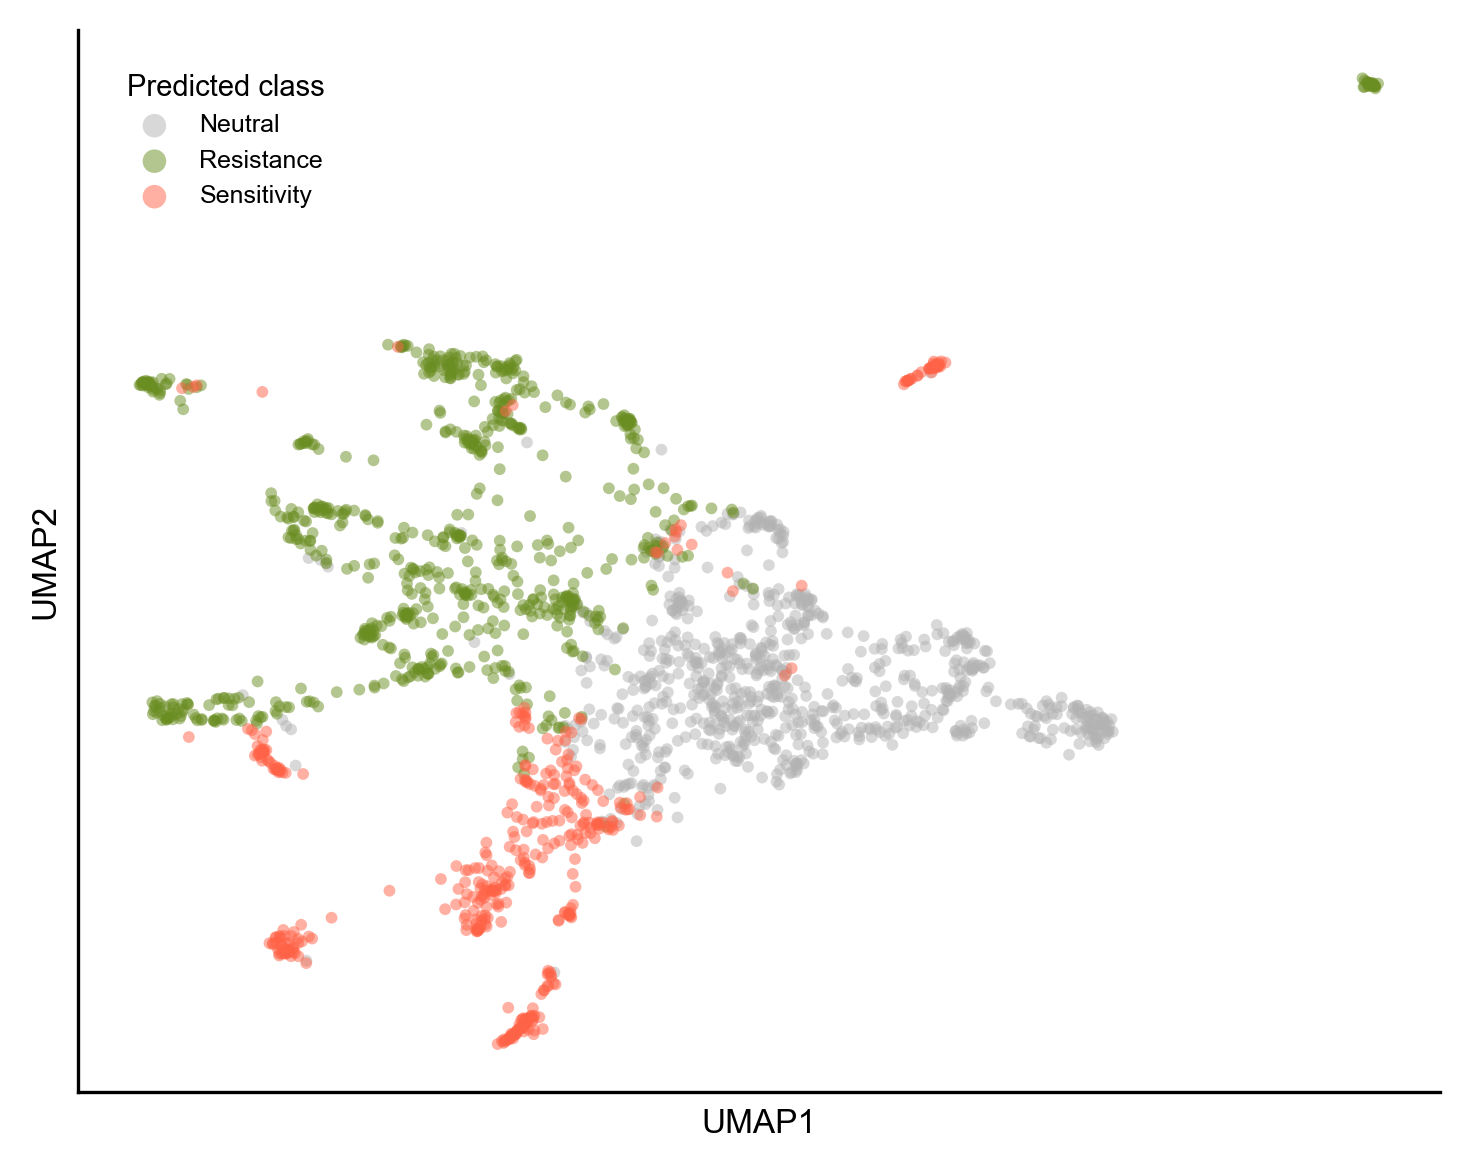

In [39]:
# UMAP colored by predicted class
class_labels = {i: c for i, c in enumerate(le.classes_)}
class_colors = {
    0: "#b3b3b3",
    1: "olivedrab",
    2: "tomato",
}

plt.figure(figsize=(5, 4))

for class_idx in np.unique(y_pred_final):
    mask = y_pred_final == class_idx

    plt.scatter(
        embed_pred[mask, 0],
        embed_pred[mask, 1],
        c=class_colors[class_idx],
        label=class_labels[class_idx],
        s=8,
        alpha=0.5,
        edgecolors='none',
        linewidths=0
    )

plt.xlabel("UMAP1", fontsize=8)

plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)
plt.legend(title="Predicted class", markerscale=2, fontsize=6, title_fontsize=7, loc="upper left", frameon=False, bbox_to_anchor=(0.02, 0.98))
plt.grid(False)
plt.tight_layout()
plt.show()

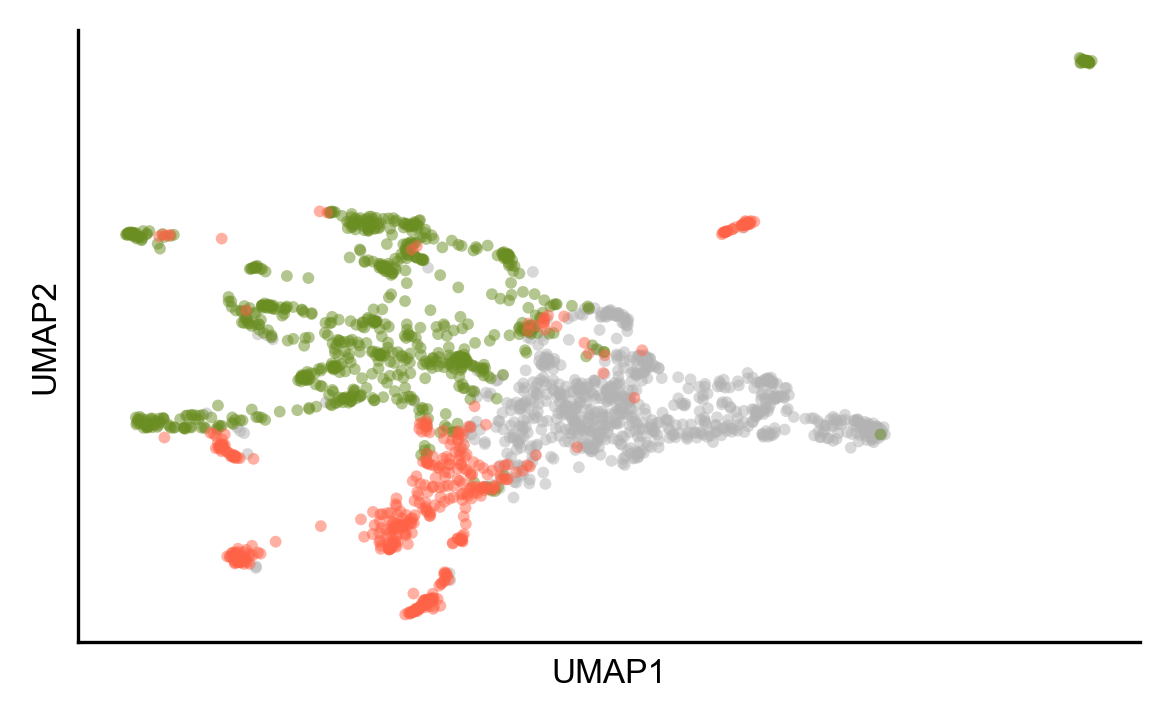

In [79]:
# UMAP colored by true class
class_labels = {i: c for i, c in enumerate(le.classes_)}
class_colors = {
    0: "#b3b3b3",
    1: "olivedrab",
    2: "tomato",
}

plt.figure(figsize=(4, 2.5))

for class_idx in np.unique(y):
    mask = y == class_idx

    plt.scatter(
        embed_pred[mask, 0],
        embed_pred[mask, 1],
        c=class_colors[class_idx],
        label=class_labels[class_idx],
        s=8,
        alpha=0.5,
        edgecolors='none',
        linewidths=0
    )

plt.xlabel("UMAP1", fontsize=8)

plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)
#plt.legend(title="True class", markerscale=2, fontsize=5, title_fontsize=6, loc="upper left", frameon=False, bbox_to_anchor=(0.02, 1.01))
plt.grid(False)
plt.tight_layout()
plt.show()

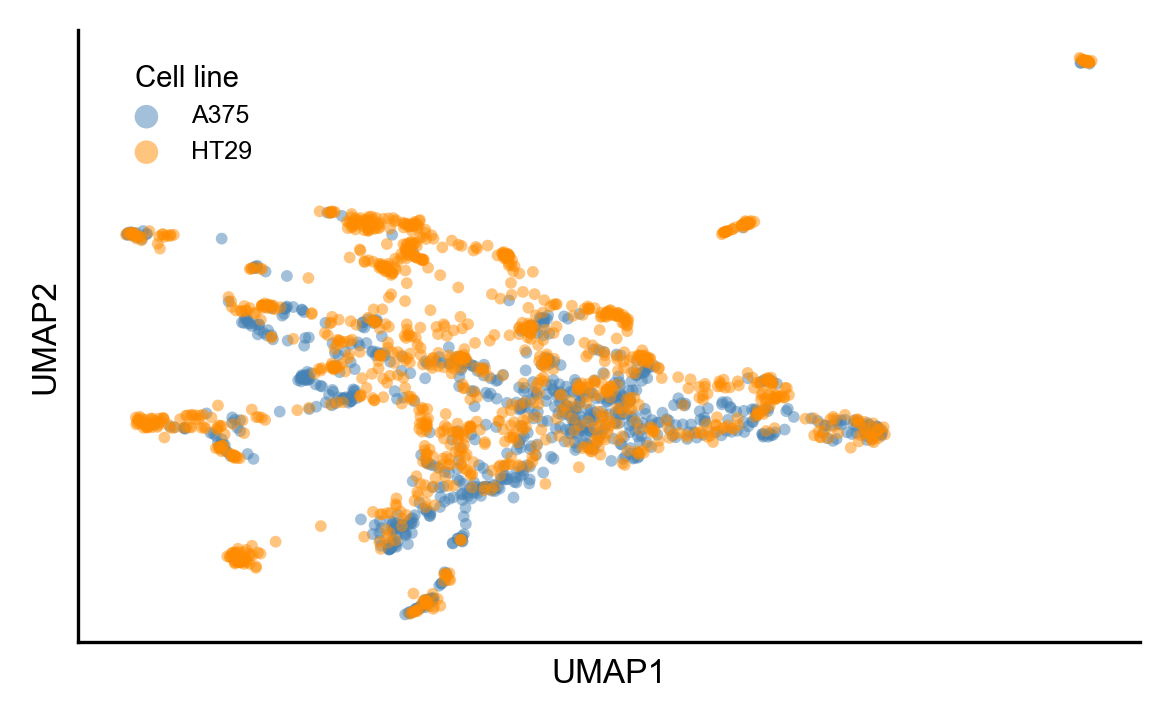

In [86]:
# UMAP colored by CELL LINE

cell_lines = meta_data["Cell_Line"].values

# Sanity check
assert len(cell_lines) == embed_pred.shape[0]

# Define labels and colors 
unique_cell_lines = np.unique(cell_lines)

cell_line_colors = {
    unique_cell_lines[0]: "steelblue",
    unique_cell_lines[1]: "darkorange",
}

# Plot UMAP colored by cell line
plt.figure(figsize=(4, 2.5))

for cl in unique_cell_lines:
    mask = cell_lines == cl
    plt.scatter(
        embed_pred[mask, 0],
        embed_pred[mask, 1],
        c=cell_line_colors[cl],
        label=cl,
        s=8,
        alpha=0.5,
        edgecolors='none',
        linewidths=0 
    )

plt.xlabel("UMAP1", fontsize=8)
plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)
plt.legend(title="Cell line", markerscale=2, fontsize=6, title_fontsize=7, loc="upper left", frameon=False, bbox_to_anchor=(0.02, 0.98))
plt.tight_layout()
plt.show()

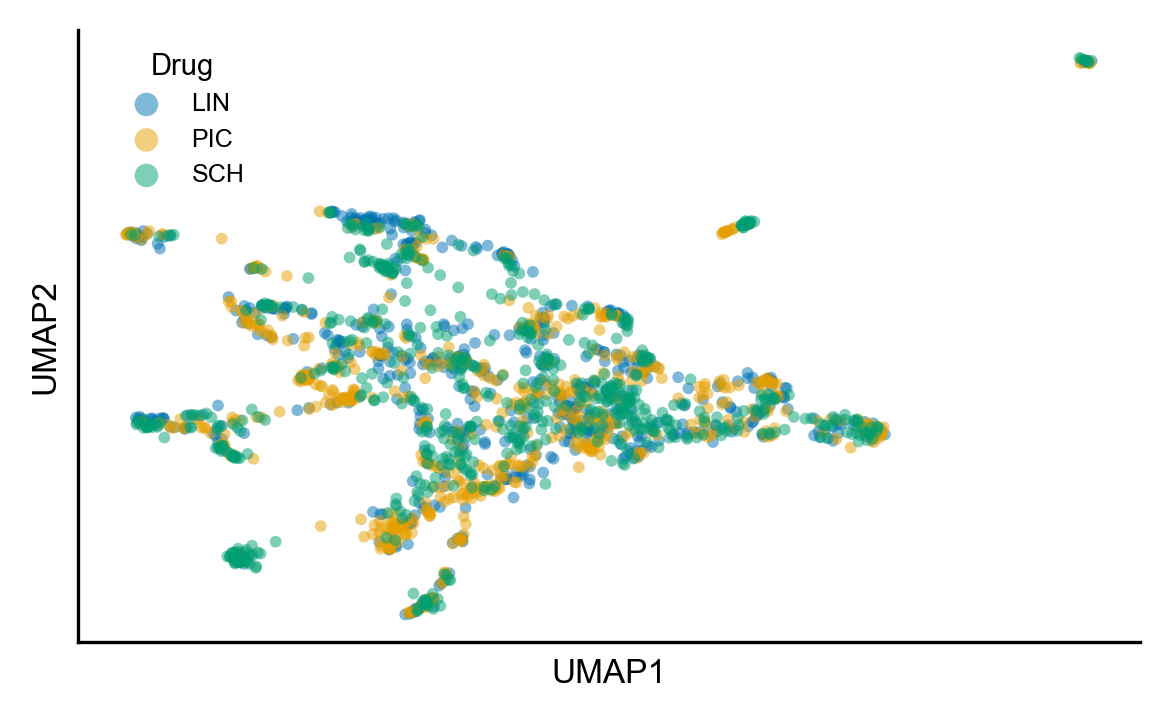

In [89]:
# UMAP colored by drug

drugs = meta_data["Drug"].values

# Sanity check
assert len(drugs) == embed_pred.shape[0]

# Define labels and colors 
unique_drug = np.unique(drugs)

drug_colors = {
    unique_drug[0]: "#0072B2",
    unique_drug[1]: "#E69F00",
    unique_drug[2]: "#009E73",
}

plt.figure(figsize=(4, 2.5))

for drug in unique_drug:
    mask = drugs == drug
    plt.scatter(
        embed_pred[mask, 0],
        embed_pred[mask, 1],
        c=drug_colors[drug],
        label=drug,
        s=8,
        alpha=0.5,
        edgecolors='none',
        linewidths=0 
    )

plt.xlabel("UMAP1", fontsize=8)
plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)
plt.legend(title="Drug", markerscale=2, fontsize=6, title_fontsize=7, loc="upper left", frameon=False, bbox_to_anchor=(0.02, 1))
plt.tight_layout()
plt.show()

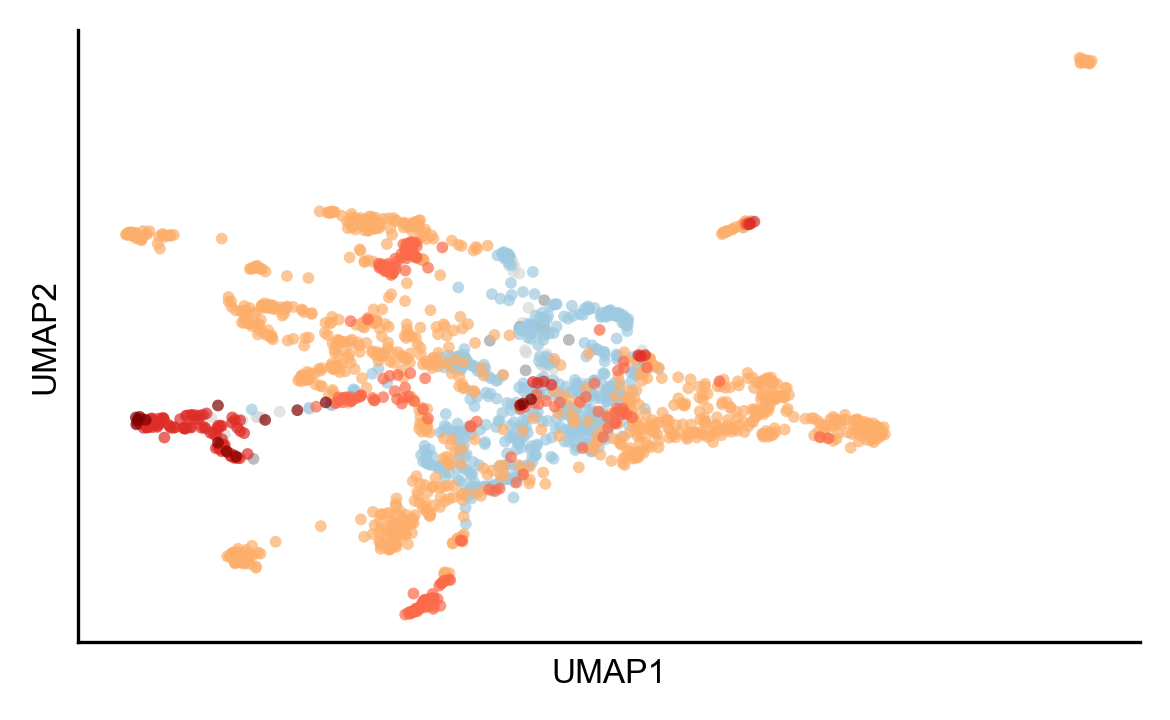

In [82]:
#Color by mutation categ
mutation_enc = X["Mutation_Category_enc"].values

mutation_labels = {
    0: "Intron",
    1: "UTR",
    2: "Silent",
    3: "Missense",
    4: "Nonsense",
    5: "Splice-acceptor",
    6: "Splice-donor",
}


mutation_colors = {
    0: "#d9d9d9",  # Intron (light grey)
    1: "#9e9e9e",  # UTR (grey)
    2: "#9ecae1",  # Silent (light blue)
    3: "#fdae6b",  # Missense (orange)
    4: "#fb6a4a",  # Nonsense (red-orange)
    5: "#de2d26",  # Splice-acceptor (strong red)
    6: "#7f0000",  # Splice-donor (dark red)
}

mutation_colors_x = {
    0: "#bdbdbd",  # Intron (stronger grey)
    1: "#7f7f7f",  # UTR (darker grey)
    2: "#6baed6",  # Silent (stronger blue)
    3: "#f16913",  # Missense (stronger orange)
    4: "#ef3b2c",  # Nonsense (red-orange)
    5: "#cb181d",  # Splice-acceptor (strong red)
    6: "#99000d",  # Splice-donor (deep red)
}

mutation_colors_x = {
    0: "#bdbdbd",  # Intron
    1: "#7f7f7f",  # UTR
    2: "#6baed6",  # Silent
    3: "#f16913",  # Missense
    4: "#ef3b2c",  # Nonsense (red-orange)
    5: "#756bb1",  # Splice-acceptor (purple)
    6: "#99000d",  # Splice-donor (deep red)
}

plt.figure(figsize=(4, 2.5))

for m in np.unique(mutation_enc):
    mask = mutation_enc == m

    plt.scatter(
        embed_pred[mask, 0],
        embed_pred[mask, 1],
        c=mutation_colors[m],
        label=mutation_labels[m],
        s=8,
        alpha=0.7,
        edgecolors='none',
        linewidths=0 
    )

plt.xlabel("UMAP1", fontsize=8)
plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)
#plt.legend(title="Mutation Category", markerscale=2, fontsize=5, title_fontsize=6, loc="upper left", bbox_to_anchor=(0.02, 1.5))
plt.tight_layout()
plt.show()

In [34]:
#Color by pathway category of the mutated gene 
cell_surface_recept = [
    'EGFR',
    'FGFR2',
    'ERBB2',
    'ERBB3'
]

adaptor_proteins = [
    'GAB1',
    'GRB2',
    'SHC1'
]

mapk_erk = [
    'KRAS',
    'NRAS',
    'HRAS',
    'BRAF',
    'RAF1',
    'MAP2K1',
    'MAP2K2',
    'MAPK3',
    'MAPK1'
]

pi3k_akt_mtor = [
    'PIK3CA',
    'PIK3CB',
    'PIK3CD',
    'PTEN',
    'AKT1', 
    'MTOR',
    'RICTOR'
]

def assign_pathway(gene):
    if gene in cell_surface_recept:
        return "Cell Surface Receptor"
    elif gene in adaptor_proteins:
        return "Adaptor Protein"
    elif gene in mapk_erk:
        return "MAPK/ERK"
    elif gene in pi3k_akt_mtor:
        return "PI3K/AKT/mTOR"
    else:
        return "Other"

pathway_labels = meta_data["Gene"].apply(assign_pathway).values


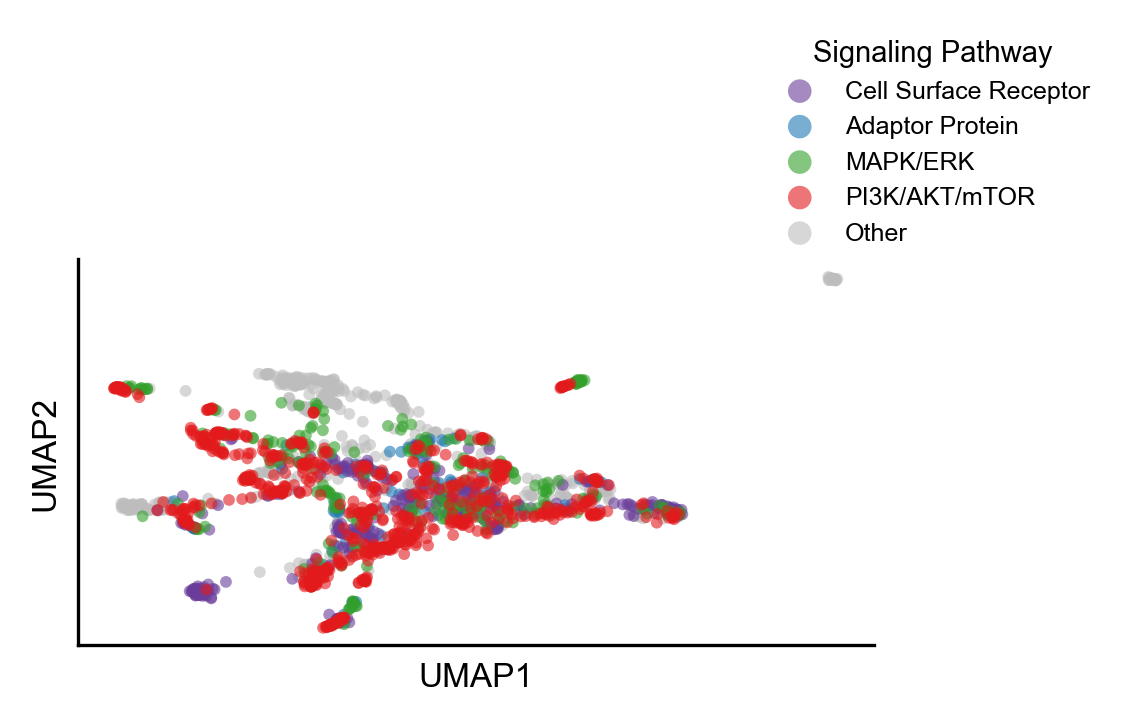

In [93]:
pathway_colors = {
    "Cell Surface Receptor": "#6A3D9A",              # purple (upstream receptors)
    "Adaptor Protein": "#1F78B4",          # blue
    "MAPK/ERK": "#33A02C",         # green
    "PI3K/AKT/mTOR": "#E31A1C",    # red
    "Other": "#BDBDBD"             # grey
}

plt.figure(figsize=(4, 2.5))

for pathway in np.unique(pathway_labels):
    mask = pathway_labels == pathway

    plt.scatter(
        embed_pred[mask, 0],
        embed_pred[mask, 1],
        c=pathway_colors[pathway],
        label=pathway,
        s=8,
        alpha=0.6,
        edgecolors='none',
        linewidths=0,
        zorder=1 if pathway == "Other" else 2
    )

plt.xlabel("UMAP1", fontsize=8)
plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)

handles, labels = plt.gca().get_legend_handles_labels()

desired_order = [
    "Cell Surface Receptor",
    "Adaptor Protein",
    "MAPK/ERK",
    "PI3K/AKT/mTOR",
    "Other"
]

ordered_handles = [handles[labels.index(l)] for l in desired_order]

plt.legend(ordered_handles, desired_order, title="Signaling Pathway", markerscale=2, fontsize=6, title_fontsize=7, loc="lower right", bbox_to_anchor=(1.3, 0.98))

plt.grid(False)
plt.tight_layout()
plt.show()

# Feature Ablation Plot

In [103]:
labels = [
    "Full\nModel",
    "Cellular +\ndrug context",
    "Ensembl\nVEP",
    "ProtVar"
]

f1_means = np.array([
    0.700,
    0.626,
    0.673,
    0.507
])

f1_stds = np.array([
    0.003,
    0.005,
    0.007,
    0.006
])

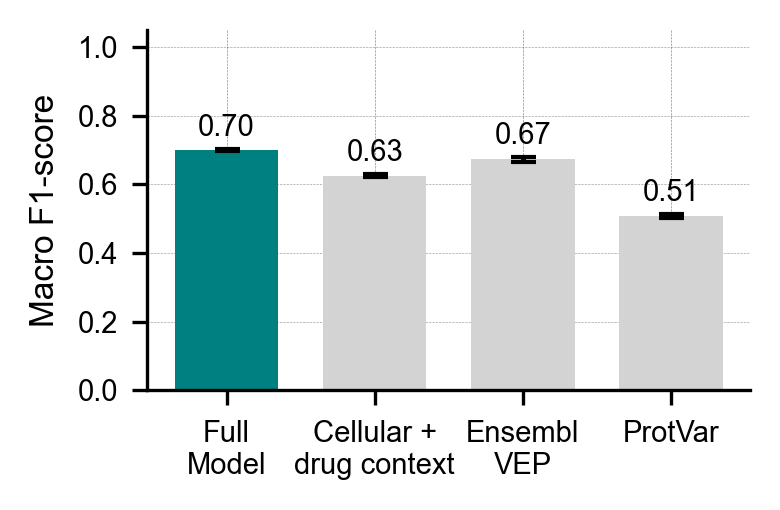

In [105]:
x = np.arange(len(labels))

plt.figure(figsize=(2.7, 1.8))

bars = plt.bar(
    x,
    f1_means,
    yerr=f1_stds,
    capsize=3,
    width=0.7,
    color=["teal", "lightgrey", "lightgrey", "lightgrey"],
    error_kw=dict(ecolor="black", lw=1.2)
)

# Add value labels
#for bar in bars:
 #   height = bar.get_height()
  #  plt.text(
   #     bar.get_x() + bar.get_width() / 2,
    #    height + 0.015,
     #   f"{height:.2f}",
      #  ha="center",
       # va="bottom",
        #fontsize=9
    #)

#plt.xticks(x, labels, fontsize=8)
#plt.ylabel("Macro F1-score", fontsize=9)
#plt.yticks(fontsize=9)
#plt.ylim(0.45, 0.75)
#plt.grid(axis="y", linestyle="--", alpha=0.4)
#plt.tight_layout()
#plt.show()

for i, bar in enumerate(bars):
    mean = f1_means[i]
    std = f1_stds[i]

    plt.text(bar.get_x() + bar.get_width()/2,
             mean + std + 0.02,
             f"{mean:.2f}",
             ha='center', va='bottom', fontsize=7)


plt.xticks(x, labels, fontsize=7)
plt.ylabel("Macro F1-score", fontsize=8)
plt.yticks(fontsize=7)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Benchmarking F1 Plot

In [100]:
labels = [
    "CL\nHT29",
    "CL\nA375",
    "VH",
    "DG\nSCH",
    "DG\nLIN",
    "DG\nPIC"
]

f1_means = np.array([
    0.360,
    0.365,
    0.677,
    0.393,
    0.634,
    0.485
])

f1_stds = np.array([
    0.020,
    0.013,
    0.005,
    0.010,
    0.011,
    0.011
])

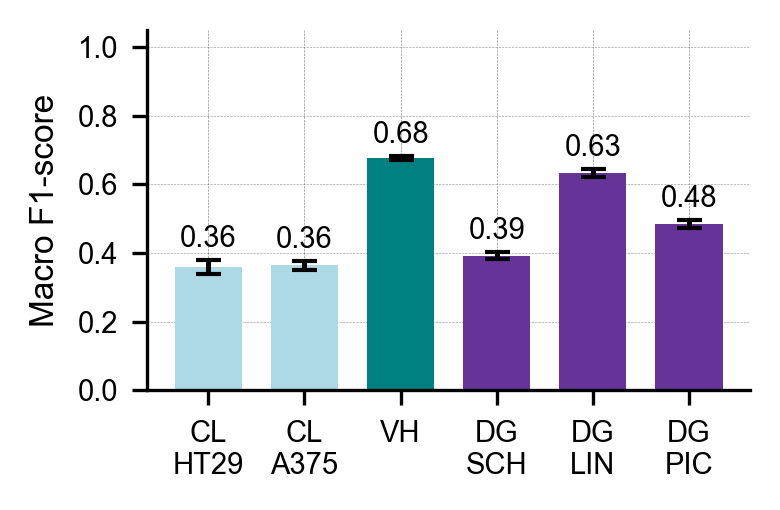

In [101]:
x = np.arange(len(labels))

plt.figure(figsize=(2.7, 1.8))

bars = plt.bar(
    x,
    f1_means,
    yerr=f1_stds,
    capsize=3,
    width=0.7,
    color=["lightblue", "lightblue", "teal", "rebeccapurple", "rebeccapurple", "rebeccapurple"],
    error_kw=dict(ecolor="black", lw=1.2)
)

# Add value labels
#for bar in bars:
 #   height = bar.get_height()
  #  plt.text(
   #     bar.get_x() + bar.get_width() / 2,
    #    height + 0.015,
     #   f"{height:.2f}",
      #  ha="center",
       # va="bottom",
        #fontsize=9
    #)

#plt.xticks(x, labels, fontsize=8)
#plt.ylabel("Macro F1-score", fontsize=9)
#plt.yticks(fontsize=9)
#plt.ylim(0.45, 0.75)
#plt.grid(axis="y", linestyle="--", alpha=0.4)
#plt.tight_layout()
#plt.show()

for i, bar in enumerate(bars):
    mean = f1_means[i]
    std = f1_stds[i]

    plt.text(bar.get_x() + bar.get_width()/2,
             mean + std + 0.02,
             f"{mean:.2f}",
             ha='center', va='bottom', fontsize=7)


plt.xticks(x, labels, fontsize=7)
plt.ylabel("Macro F1-score", fontsize=8)
plt.yticks(fontsize=7)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [34]:
#Split dataset into features and labels
X = annotated_variants_df_balanced.drop(columns=meta_cols + ["Class_encoded"])
y = annotated_variants_df_balanced["Class_encoded"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2027, 68)
Label vector shape: (2027,)


In [35]:
X.head()

,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,3.0,2.0,NaN,0.0,0.903,NaN,0.997184,NaN,0.8033,-0.244790,0.999174,0.560625,-13.162,3.091224,0.180899,4.35,3.44,NaN,0.96529,NaN,NaN,0.685240,-1.0463,0.871099,1.385,NaN,0.0,0.910088,969.0,0.905758,NaN,1.0,7.806,32.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,0.474,1.64656,NaN,6.912422,2.19480,93.95,0.799517,94.146400,939.715467,-0.066729,1.0,14.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,0.724616,2.0,0.0
1,3.0,2.0,NaN,0.0,0.526,NaN,0.980654,NaN,0.8695,-0.086449,0.997541,0.900511,-13.449,4.195272,0.376379,3.86,3.86,NaN,0.81667,NaN,NaN,0.838982,-0.8432,0.879321,1.935,NaN,0.0,0.797818,969.0,0.962908,NaN,1.0,7.985,28.800,9.733,-0.391,9.342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.474,1.23992,0.740776,6.912422,0.85641,86.97,0.790631,69.093103,771.002071,-0.066729,0.0,0.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,0.724616,2.0,0.0
2,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.474,-0.01280,NaN,6.912422,NaN,NaN,0.847171,86.512545,983.000586,-0.066729,0.0,0.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,-0.905239,1.0,0.0
3,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.474,NaN,NaN,6.912422,NaN,NaN,NaN,NaN,NaN,-0.066729,NaN,NaN,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,-0.905239,1.0,0.0
4,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.474,0.00446,NaN,6.912422,NaN,NaN,NaN,NaN,NaN,-0.066729,0.0,0.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,0.311144,1.0,0.0


### Assessing robustness of Hyperparameters

In [86]:
params = {
    "n_estimators": [50, 100, 200, 300, 500, 700, 1000],  # number of boosting rounds
    "max_depth": [3, 6, 9, 10],                         
    "learning_rate": [0.01, 0.05, 0.07, 0.1, 0.2],              
    "subsample": [0.5, 0.7, 0.85, 1.0],                  # defines the fraction of training instances to be used for each tree
    "colsample_bytree": [0.5, 0.7, 0.85, 1.0],           # feature sampling
    "min_child_weight": [1, 3, 5],                  # min sum of instance weight in child
    "reg_alpha": [0, 0.01, 0.1, 1, 1.5],         # L1 regularization
    "reg_lambda": [0, 0.01, 0.5, 0.7, 1, 1.5],               # L2 regularization
    "gamma": [0, 0.05, 0.1, 0.3, 0.5, 1]                     # min loss reduction to make a further partition
}

In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
outer_results_per_fold = []  

for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"\nOuter fold {fold_id}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] #X_test and y_test won't be used, it's just to hide part of the data from the hyperparameter tuning

    #Hyperparameter tuning 
    xgb = XGBClassifier(
    objective="multi:softprob", 
    num_class=len(le.classes_), 
    random_state=1
    )

    # Stratified K-Fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=params,
        n_iter=100,               
        scoring="f1_macro",    
        cv=cv,
        verbose=2,
        random_state=1,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    #Store best params and score for this outer fold
    best_params_fold = random_search.best_params_
    best_score_fold = random_search.best_score_

    outer_results_per_fold.append({
        "fold": fold_id,
        "best_score_inner_cv": best_score_fold,
        **best_params_fold
    })

    results_df = pd.DataFrame(outer_results_per_fold)
    results_df

In [88]:
results_df

,fold,best_score_inner_cv,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree
0,1,0.698712,0.85,1.0,0.01,300,1,6,0.01,1.00
1,2,0.711460,0.70,1.0,0.01,300,1,6,0.01,0.70
2,3,0.706105,0.85,1.3,1.00,1000,3,9,0.01,1.00
3,4,0.691758,0.85,1.3,0.10,300,3,9,0.01,0.85
4,5,0.694344,1.00,0.5,0.10,100,3,9,0.20,1.00


In [70]:
#Best f1 score mean + std variation
mean_best_score = results_df["best_score_inner_cv"].mean()
std_best_score = results_df["best_score_inner_cv"].std()
print(f"\nMean best score across outer folds: {mean_best_score:.4f} ± {std_best_score:.4f}")


Mean best score across outer folds: 0.7005 ± 0.0082


In [71]:
results_df["learning_rate"].value_counts(normalize=True)

learning_rate
0.01    0.8
0.20    0.2
Name: proportion, dtype: float64

In [80]:
results_df["colsample_bytree"].value_counts(normalize=True)

colsample_bytree
1.00    0.6
0.70    0.2
0.85    0.2
Name: proportion, dtype: float64

In [67]:
results_df.to_csv("/Users/carolinapinto/desktop/Tese/xgb_hyperparameter_tuning_outer_cv_results.csv", index=False)

## Optuna Bayesian Optimization

In [36]:
#Define objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.5, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 1.5, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "objective": "multi:softprob",
        "num_class": len(le.classes_),
        "random_state": 1,
        "n_jobs": -1,
        }
    
    #Stratified Cross Validation
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    cv_fold_scores = []
    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        score = f1_score(y_test, y_pred, average='macro')
        cv_fold_scores.append(score)

    avg_score = np.mean(cv_fold_scores)
    return avg_score

In [37]:
#Define study and optimize
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=2))
study.optimize(objective, n_trials=500)

[I 2026-02-10 11:50:37,507] A new study created in memory with name: no-name-f8331cc8-46c3-4d11-83a7-b4a8178cc395
[I 2026-02-10 11:50:44,001] Trial 0 finished with value: 0.6917592674933462 and parameters: {'n_estimators': 492, 'max_depth': 3, 'learning_rate': 0.06485121677838487, 'subsample': 0.7176611963091384, 'colsample_bytree': 0.7101839010437445, 'min_child_weight': 2, 'reg_alpha': 0.0007155358071378653, 'reg_lambda': 0.038559560000344564, 'gamma': 0.29965467367452314}. Best is trial 0 with value: 0.6917592674933462.
[I 2026-02-10 11:50:52,115] Trial 1 finished with value: 0.7026246793531546 and parameters: {'n_estimators': 340, 'max_depth': 7, 'learning_rate': 0.060479338757937, 'subsample': 0.5672899726724667, 'colsample_bytree': 0.7567890606328732, 'min_child_weight': 1, 'reg_alpha': 0.1903843502824323, 'reg_lambda': 0.36836533572301006, 'gamma': 0.4942368373819278}. Best is trial 1 with value: 0.7026246793531546.
[I 2026-02-10 11:51:03,041] Trial 2 finished with value: 0.6844

In [38]:
study.best_value

0.7173864273064182

In [39]:
study.best_params


{'n_estimators': 473,
 'max_depth': 8,
 'learning_rate': 0.014757846958987166,
 'subsample': 0.9074779169306355,
 'colsample_bytree': 0.5480484893807359,
 'min_child_weight': 1,
 'reg_alpha': 0.0004937375718649116,
 'reg_lambda': 0.000319094062330884,
 'gamma': 0.6244886434704836}

In [40]:
study.trials_dataframe().sort_values("value", ascending=False).head(20)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
291,291,0.717386,2026-02-10 12:42:21.286215,2026-02-10 12:42:35.408512,0 days 00:00:14.122297,0.548048,0.624489,0.014758,8,1,473,0.000494,0.000319,0.907478,COMPLETE
341,341,0.716951,2026-02-10 12:54:44.459257,2026-02-10 12:55:01.564300,0 days 00:00:17.105043,0.565865,0.510307,0.012138,7,1,541,0.000140,0.000133,0.891980,COMPLETE
316,316,0.715692,2026-02-10 12:48:26.556352,2026-02-10 12:48:42.457720,0 days 00:00:15.901368,0.569020,0.631246,0.011395,7,1,504,0.000268,0.000119,0.912414,COMPLETE
303,303,0.715293,2026-02-10 12:45:06.148938,2026-02-10 12:45:21.117676,0 days 00:00:14.968738,0.545435,0.685855,0.011376,7,1,477,0.000941,0.000257,0.918478,COMPLETE
419,419,0.715244,2026-02-10 13:15:35.824787,2026-02-10 13:15:54.347090,0 days 00:00:18.522303,0.564392,0.338458,0.013640,7,1,590,0.000121,0.000193,0.893862,COMPLETE
348,348,0.715157,2026-02-10 12:56:40.170339,2026-02-10 12:56:57.379383,0 days 00:00:17.209044,0.571069,0.498973,0.011153,7,1,524,0.001125,0.000164,0.907089,COMPLETE
226,226,0.714917,2026-02-10 12:30:39.327914,2026-02-10 12:30:46.433414,0 days 00:00:07.105500,0.566351,0.565965,0.027843,8,1,184,0.006868,0.000753,0.988396,COMPLETE
347,347,0.714904,2026-02-10 12:56:22.912209,2026-02-10 12:56:40.168998,0 days 00:00:17.256789,0.566599,0.502449,0.011223,7,1,525,0.000935,0.000188,0.909217,COMPLETE
398,398,0.714865,2026-02-10 13:09:43.591233,2026-02-10 13:10:00.093688,0 days 00:00:16.502455,0.548969,0.456102,0.013601,7,1,558,0.000194,0.000130,0.892228,COMPLETE
401,401,0.714851,2026-02-10 13:10:31.824374,2026-02-10 13:10:47.589829,0 days 00:00:15.765455,0.542533,0.458762,0.015108,7,1,588,0.000147,0.000139,0.891232,COMPLETE


In [41]:
optuna.visualization.plot_optimization_history(study)

In [42]:
optuna.visualization.plot_param_importances(study)

## Check Robustness to non-hit subsamples

In [117]:
numb_runs = 5
results = []

for ds_seed in range(numb_runs):
    print(f"\n=== Running Optuna with downsampling seed {ds_seed} ===")

    # 1. Downsample non-hits
    df_balanced = stratified_downsampling(annotated_variants_df, class_col='Class', random_state=ds_seed)
    
    print("Class distribution after downsampling:")
    print(df_balanced['Class'].value_counts())

    # 2. Build X, y
    X = df_balanced.drop(columns=meta_cols + ["Class_encoded"])
    y = df_balanced["Class_encoded"]

    # 3. Define objective
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.5, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 1.5, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 1.0),
            "objective": "multi:softprob",
            "num_class": len(le.classes_),
            "random_state": 1,
            "n_jobs": -1,
        }

        kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
        fold_scores = []

        for train_idx, test_idx in kf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model = XGBClassifier(**params)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            score = f1_score(y_test, y_pred, average="macro")
            fold_scores.append(score)

        return np.mean(fold_scores)

    # 4. Run Optuna
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=2)
    )
    study.optimize(objective, n_trials=250)

    # 5. Store results
    results.append({
        "downsample_seed": ds_seed,
        "best_score": study.best_value,
        **study.best_params
    })


=== Running Optuna with downsampling seed 0 ===


[I 2026-02-06 09:25:58,848] A new study created in memory with name: no-name-76947fd8-1dd8-4187-ae82-648ccfbd71c1


Class distribution after downsampling:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64


[I 2026-02-06 09:26:05,438] Trial 0 finished with value: 0.6718399093794989 and parameters: {'n_estimators': 492, 'max_depth': 3, 'learning_rate': 0.06485121677838487, 'subsample': 0.7176611963091384, 'colsample_bytree': 0.7101839010437445, 'min_child_weight': 2, 'reg_alpha': 0.0007155358071378653, 'reg_lambda': 0.038559560000344564, 'gamma': 0.29965467367452314}. Best is trial 0 with value: 0.6718399093794989.
[I 2026-02-06 09:26:13,771] Trial 1 finished with value: 0.677442892451499 and parameters: {'n_estimators': 340, 'max_depth': 7, 'learning_rate': 0.060479338757937, 'subsample': 0.5672899726724667, 'colsample_bytree': 0.7567890606328732, 'min_child_weight': 1, 'reg_alpha': 0.1903843502824323, 'reg_lambda': 0.36836533572301006, 'gamma': 0.4942368373819278}. Best is trial 1 with value: 0.677442892451499.
[I 2026-02-06 09:26:24,838] Trial 2 finished with value: 0.6782256341234512 and parameters: {'n_estimators': 862, 'max_depth': 3, 'learning_rate': 0.05575832752388716, 'subsample'


=== Running Optuna with downsampling seed 1 ===


...

[I 2026-02-06 11:54:57,274] Trial 0 finished with value: 0.6816709987763507 and parameters: {'n_estimators': 492, 'max_depth': 3, 'learning_rate': 0.06485121677838487, 'subsample': 0.7176611963091384, 'colsample_bytree': 0.7101839010437445, 'min_child_weight': 2, 'reg_alpha': 0.0007155358071378653, 'reg_lambda': 0.038559560000344564, 'gamma': 0.29965467367452314}. Best is trial 0 with value: 0.6816709987763507.
[I 2026-02-06 11:55:05,349] Trial 1 finished with value: 0.6989934155229452 and parameters: {'n_estimators': 340, 'max_depth': 7, 'learning_rate': 0.060479338757937, 'subsample': 0.5672899726724667, 'colsample_bytree': 0.7567890606328732, 'min_child_weight': 1, 'reg_alpha': 0.1903843502824323, 'reg_lambda': 0.36836533572301006, 'gamma': 0.4942368373819278}. Best is trial 1 with value: 0.6989934155229452.
[I 2026-02-06 11:55:15,716] Trial 2 finished with value: 0.6864687535529979 and parameters: {'n_estimators': 862, 'max_depth': 3, 'learning_rate': 0.05575832752388716, 'subsampl


=== Running Optuna with downsampling seed 4 ===


[I 2026-02-06 12:32:50,908] A new study created in memory with name: no-name-0a78e36f-d14e-4169-ac6c-fd5cef7f8ec2


Class distribution after downsampling:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64


[I 2026-02-06 12:32:56,861] Trial 0 finished with value: 0.6824119593763112 and parameters: {'n_estimators': 492, 'max_depth': 3, 'learning_rate': 0.06485121677838487, 'subsample': 0.7176611963091384, 'colsample_bytree': 0.7101839010437445, 'min_child_weight': 2, 'reg_alpha': 0.0007155358071378653, 'reg_lambda': 0.038559560000344564, 'gamma': 0.29965467367452314}. Best is trial 0 with value: 0.6824119593763112.
[I 2026-02-06 12:33:04,960] Trial 1 finished with value: 0.6925666721326637 and parameters: {'n_estimators': 340, 'max_depth': 7, 'learning_rate': 0.060479338757937, 'subsample': 0.5672899726724667, 'colsample_bytree': 0.7567890606328732, 'min_child_weight': 1, 'reg_alpha': 0.1903843502824323, 'reg_lambda': 0.36836533572301006, 'gamma': 0.4942368373819278}. Best is trial 1 with value: 0.6925666721326637.
[I 2026-02-06 12:33:15,335] Trial 2 finished with value: 0.6736253576997228 and parameters: {'n_estimators': 862, 'max_depth': 3, 'learning_rate': 0.05575832752388716, 'subsampl

In [118]:
results_df = pd.DataFrame(results)

In [4]:
results_df.head()

,downsample_seed,best_score,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,gamma
0,0,0.702751,165,10,0.015337,0.653156,0.522484,1,0.074922,0.001445,0.776019
1,1,0.714917,184,8,0.027843,0.988396,0.566351,1,0.006868,0.000753,0.565965
2,2,0.709720,495,6,0.015971,0.957140,0.500132,1,0.207057,0.000123,0.284710
3,3,0.712203,263,10,0.032042,0.922471,0.526184,1,0.001292,0.000136,0.001754
4,4,0.715809,367,6,0.025263,0.991001,0.521444,3,0.003372,0.000495,0.050942


In [120]:
results_df.to_csv("/Users/carolinapinto/desktop/Tese/xgb_optuna_results_across_downsampling_seeds.csv", index=False)

In [6]:
mean_best_score = results_df["best_score"].mean()
std_best_score = results_df["best_score"].std()
print(f"\nMean best score across outer folds: {mean_best_score:.4f} ± {std_best_score:.4f}")


Mean best score across outer folds: 0.7111 ± 0.0052
